# Capstone Project Modul 3 — Telkomsel
**Axellia Verda Qania** — Job Connector Business Data Analytics, Purwadhika

---

# 1. Latar Belakang

Telkomsel merupakan salah satu operator seluler terbesar di Indonesia, dengan puluhan juta pelanggan yang menggunakan layanan data setiap hari. Untuk menarik pelanggan baru, Telkomsel menjalankan program **Device Bundling** — pelanggan membeli perangkat (iPhone atau Samsung) dan memperoleh paket kuota dalam jumlah besar dengan harga yang jauh lebih murah dibandingkan harga normal.

Program ini menguntungkan bagi pelanggan, namun **mahal bagi perusahaan**. Telkomsel menanggung subsidi di awal, dengan harapan pelanggan tersebut bertahan dalam jangka panjang sehingga subsidi tersebut kembali melalui pendapatan berulang.

### Celah yang muncul

Di lapangan, muncul praktik penyalahgunaan: sebagian pihak membeli paket bundling, **menjual perangkatnya secara terpisah**, lalu memindahkan kartu SIM ke modem WiFi atau ponsel murah untuk menjual kuotanya secara eceran. Telkomsel kehilangan subsidi, dan tidak memperoleh pelanggan setia sebagai gantinya.

### Satu-satunya alat kontrol: IMEI

Untuk mencegah hal tersebut, Telkomsel mengandalkan **pencocokan IMEI**.

**IMEI** (*International Mobile Equipment Identity*) adalah nomor identitas 15 digit yang melekat pada **fisik perangkat** — bukan pada nomor teleponnya, bukan pada kartu SIM-nya. 

Karena itu, IMEI dapat digunakan untuk memastikan kuota bersubsidi benar-benar dipakai pada perangkat yang didaftarkan:

| Kolom | Arti |
|---|---|
| `registered_imei` | IMEI perangkat yang **didaftarkan** saat pembelian paket bundling |
| `used_imei` | IMEI perangkat yang **benar-benar dipakai** pada sesi internet tersebut |

Apabila keduanya berbeda, artinya kartu SIM tersebut sedang digunakan pada perangkat lain — dan hal ini menjadi indikasi penyalahgunaan.

### Masalahnya

Kontrol ini **belum pernah diuji keandalannya**. Padahal, apabila data IMEI-nya sendiri tidak akurat, Telkomsel menanggung dua risiko sekaligus: **salah menindak pelanggan yang jujur**, sekaligus **gagal melihat penyalahgunaan yang benar-benar terjadi**.

Sebelum data ini dipakai sebagai dasar penindakan, kelayakannya perlu diperiksa terlebih dahulu.

# 2. Pernyataan Masalah

**Masalah utama:**

> Telkomsel mengandalkan pencocokan IMEI sebagai **satu-satunya** kontrol untuk mengamankan subsidi program Device Bundling, namun keandalan kontrol tersebut belum pernah diuji.

**Pertanyaan utama yang akan dijawab:**

> ## *Apakah data IMEI Telkomsel cukup valid untuk dijadikan dasar menindak penyalahgunaan program Device Bundling?*

Sebagai *data analyst*, pertanyaan utama tersebut akan dijawab melalui **4 pertanyaan turunan** yang saling berkaitan — jawaban dari satu pertanyaan menjadi dasar bagi pertanyaan berikutnya:

| No | Pertanyaan Turunan | Tujuan |
|---|---|---|
| **1** | Apabila data mentah dipercaya apa adanya, **berapa besar indikasi penyalahgunaan** Device Bundling? | Mengukur skala masalah |
| **2** | **Apakah indikasi tersebut valid?** Benarkah berasal dari perpindahan perangkat oleh pelanggan? | Menguji temuan sendiri |
| **3** | Apabila bukan perilaku pelanggan, **apakah polanya menunjukkan error sistem**? | Menemukan akar masalah |
| **4** | **Kejanggalan pencatatan apa lagi** yang ada di luar IMEI, dan berapa pelanggan yang terdampak? | Mengukur dampak menyeluruh |

# 3. Data

Analisis ini menggunakan **3 tabel** yang saling berhubungan.

### 3.1 `tsel_subscribers` — data pelanggan
Satu baris mewakili satu nomor HP.

| Kolom | Tipe | Keterangan |
|---|---|---|
| `msisdn` | teks | Nomor HP pelanggan (*primary key*) |
| `activation_date` | tanggal | Tanggal kartu SIM diaktifkan |
| `nik_kk_status` | kategori | Status verifikasi NIK/KK saat registrasi |
| `registered_imei` | teks | IMEI perangkat yang didaftarkan saat membeli paket bundling. **Kosong apabila pelanggan bukan peserta bundling** |

### 3.2 `tsel_packages` — data paket
Satu baris mewakili satu jenis paket.

| Kolom | Tipe | Keterangan |
|---|---|---|
| `package_code` | teks | Kode paket (*primary key*) |
| `package_name` | teks | Nama paket |
| `price` | angka | Harga paket dalam Rupiah |

### 3.3 `tsel_data_usage` — catatan pemakaian internet 
Satu baris mewakili satu sesi pemakaian internet.

| Kolom | Tipe | Keterangan |
|---|---|---|
| `session_id` | teks | ID sesi (*primary key*) |
| `msisdn` | teks | Nomor HP pelanggan (*foreign key* ke `tsel_subscribers`) |
| `package_code` | teks | Kode paket yang dipakai (*foreign key* ke `tsel_packages`) |
| `used_imei` | teks | IMEI perangkat yang benar-benar dipakai pada sesi ini |
| `session_time` | tanggal-waktu | Waktu sesi berlangsung |
| `network_type` | kategori | Jenis jaringan (3G/4G/5G) |
| `payload_mb` | angka | Jumlah data yang dipakai pada sesi ini, dalam MB |

**Hubungan antar tabel:**

```
tsel_subscribers          tsel_packages
      │ msisdn                  │ package_code
      │                         │
      └────► tsel_data_usage ◄──┘
```

## 4. Import Library

In [1]:
# Library untuk pengolahan data
import pandas as pd
import numpy as np

# Library untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Library untuk uji statistik
from statsmodels.stats.proportion import proportions_ztest

# Pengaturan tampilan
import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

print("Semua library berhasil dimuat.")

Semua library berhasil dimuat.


## 5. Load Data

Kolom `msisdn`, `used_imei`, dan `registered_imei` sengaja dibaca sebagai **teks** (`dtype=str`) sejak awal, bukan sebagai angka. Alasannya:

1. Nomor HP diawali angka nol (contoh: `081167748491`). Apabila dibaca sebagai angka, nol di depan akan hilang menjadi `81167748491`.
2. IMEI memiliki 15 digit. Apabila dibaca sebagai angka, Python berisiko menampilkannya dalam notasi ilmiah (`3.5e+14`) sehingga presisinya terpotong.

Keduanya merupakan **kode identitas**, bukan nilai yang perlu dijumlahkan atau dirata-ratakan.

In [2]:
# Membaca ketiga file. Kolom identitas dibaca sebagai teks (str) sejak awal.
df_usage = pd.read_csv(
    'tsel_data_usage.csv',
    dtype={'msisdn': str, 'used_imei': str}
)

df_subs = pd.read_csv(
    'tsel_subscribers.csv',
    dtype={'msisdn': str, 'registered_imei': str}
)

df_package = pd.read_csv('tsel_packages.csv')

print("=== tsel_data_usage (pemakaian internet) ===")
display(df_usage.head())

print("=== tsel_subscribers (pelanggan) ===")
display(df_subs.head())

print("=== tsel_packages (paket) ===")
display(df_package)

=== tsel_data_usage (pemakaian internet) ===


,session_id,msisdn,package_code,used_imei,session_time,network_type,payload_mb
0,CDR000000001,085254880966,PKG-008,350000000003139,2023-02-12 03:33:00,4G LTE,1153.63
1,CDR000000002,085271729455,PKG-009,350000000002881,2023-04-23 21:57:00,4G,224.37
2,CDR000000003,081289374635,PKG-009,350000000007764,2023-04-29 18:38:00,4G,999999.90
3,CDR000000004,081225426120,PKG-006,350000000511814,2023-09-26 14:16:00,4G,1538.98
4,CDR000000005,085267756806,PKG-010,350000000003958,2023-04-28 02:06:00,4G LTE,1722.07


=== tsel_subscribers (pelanggan) ===


,msisdn,activation_date,nik_kk_status,registered_imei
0,081167748491,2023-01-29,Valid,NaN
1,082149168526,2023-01-04,Valid,350000000247793
2,081267992845,2023-03-23,Valid,NaN
3,082297721360,2023-07-20,Valid,NaN
4,082154897876,2023-06-18,Valid,NaN


=== tsel_packages (paket) ===


,package_code,package_name,price
0,PKG-001,Promo Perdana 15GB,25000
1,PKG-002,Promo Perdana 30GB,45000
2,PKG-003,Halo Bundling iPhone,250000
3,PKG-004,Halo Bundling Samsung,200000
4,PKG-005,Internet OMG! 50GB,110000
5,PKG-006,Internet OMG! 100GB,160000
6,PKG-007,Combo Sakti 15GB,75000
7,PKG-008,Combo Sakti 25GB,100000
8,PKG-009,Kuota Ketengan YouTube,5000
9,PKG-010,Kuota Ketengan TikTok,6000


---
# 6. Exploratory Data Analysis (EDA)

Sebelum menjawab pertanyaan bisnis, data perlu dipahami terlebih dahulu secara menyeluruh. Tahap ini bertujuan mengenali **kondisi awal** data: ukurannya, tipe datanya, di mana letak data yang kosong, apakah ada duplikasi, dan apakah ada nilai yang tidak wajar.

Tahapan EDA yang akan dilakukan:

1. Ukuran dan struktur data
2. Pemeriksaan *missing value*
3. Pemeriksaan data duplikat
4. Statistik deskriptif kolom numerik
5. Eksplorasi kolom `network_type`
6. Eksplorasi kolom `used_imei`
7. Eksplorasi kolom `nik_kk_status`
8. Eksplorasi kolom tanggal
9. Pemeriksaan hubungan antar tabel

Setiap tahap akan ditutup dengan **INSIGHT** yang menjelaskan apa yang dilakukan, apa hasilnya, dan apa alasan tindakan selanjutnya.

## 6.1 Ukuran dan Struktur Data

Langkah pertama adalah melihat ukuran (jumlah baris dan kolom) serta tipe data dari masing-masing tabel, untuk memastikan seluruh data terbaca dengan benar dan tipe datanya sudah sesuai dengan maknanya.

In [48]:
daftar_tabel = [
    ('df_usage (CDR)', df_usage),
    ('df_subs (pelanggan)', df_subs),
    ('df_package (paket)', df_package)
]

for nama, df in daftar_tabel:
    print("=" * 55)
    print(f"TABEL: {nama}")
    print("=" * 55)
    print(f"Jumlah baris  : {df.shape[0]:,}")
    print(f"Jumlah kolom  : {df.shape[1]}")
    print("\nTipe data per kolom:")
    print(df.dtypes)
    print()

TABEL: df_usage (CDR)
Jumlah baris  : 300,000
Jumlah kolom  : 7

Tipe data per kolom:
session_id                 str
msisdn                     str
package_code               str
used_imei                  str
session_time    datetime64[us]
network_type               str
payload_mb             float64
dtype: object

TABEL: df_subs (pelanggan)
Jumlah baris  : 35,000
Jumlah kolom  : 4

Tipe data per kolom:
msisdn                        str
activation_date    datetime64[us]
nik_kk_status                 str
registered_imei               str
dtype: object

TABEL: df_package (paket)
Jumlah baris  : 10
Jumlah kolom  : 3

Tipe data per kolom:
package_code      str
package_name      str
price           int64
dtype: object



> ### 📌 INSIGHT
>
> **Melakukan :** Menampilkan ukuran dan tipe data dari ketiga tabel.
>
> **Output :** `df_usage` berisi **300.000 baris × 7 kolom**, `df_subs` berisi **35.000 baris × 4 kolom**, dan `df_package` berisi **10 baris × 3 kolom**. Kolom `session_time` dan `activation_date` masih bertipe `object` (teks), bukan tanggal.
>
> **Alasan :** Kolom tanggal yang masih berupa teks **belum dapat dibandingkan** satu sama lain. Padahal perbandingan tersebut dibutuhkan untuk memeriksa apakah ada sesi yang terjadi sebelum kartu diaktifkan. Karena itu, kedua kolom tersebut akan **dikonversi menjadi tipe tanggal** pada tahap cleaning.

## 6.2 Pemeriksaan *Missing Value*

Selanjutnya dilakukan proses pemeriksaan *missing value*, yaitu mencari nilai kosong (`Null`/`NaN`) pada dataset, agar dapat ditangani sesuai dengan kebutuhan dan makna dari masing-masing kolom.

In [4]:
for nama, df in daftar_tabel:
    print("=" * 55)
    print(f"TABEL: {nama}")
    print("=" * 55)

    jumlah_kosong = df.isna().sum()
    persen_kosong = df.isna().sum() / len(df) * 100

    ringkasan = pd.DataFrame({
        'jumlah_kosong': jumlah_kosong,
        'persen_kosong': persen_kosong.round(2)
    })
    display(ringkasan)

TABEL: df_usage (CDR)


,jumlah_kosong,persen_kosong
session_id,0,0.0
msisdn,0,0.0
package_code,0,0.0
used_imei,0,0.0
session_time,0,0.0
network_type,0,0.0
payload_mb,0,0.0


TABEL: df_subs (pelanggan)


,jumlah_kosong,persen_kosong
msisdn,0,0.00
activation_date,0,0.00
nik_kk_status,5202,14.86
registered_imei,24470,69.91


TABEL: df_package (paket)


,jumlah_kosong,persen_kosong
package_code,0,0.0
package_name,0,0.0
price,0,0.0


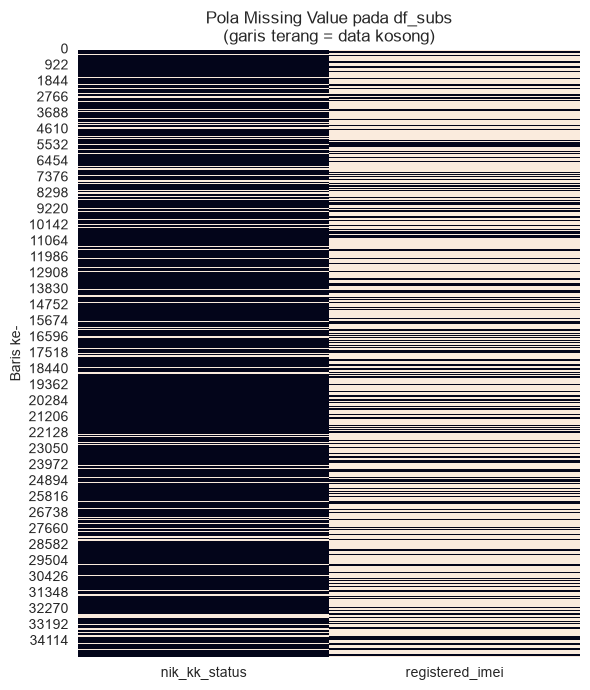

In [5]:
# Visualisasi pola missing value pada df_subs (garis terang = data kosong)
fig, ax = plt.subplots(figsize=(6, 7))
sns.heatmap(df_subs[['nik_kk_status', 'registered_imei']].isna(), cbar=False, ax=ax)
ax.set_title('Pola Missing Value pada df_subs\n(garis terang = data kosong)')
ax.set_ylabel('Baris ke-')
plt.tight_layout()
plt.show()

In [6]:
# Apakah kekosongan pada kedua kolom ini saling berkaitan?
nik_kosong = df_subs['nik_kk_status'].isna()
imei_kosong = df_subs['registered_imei'].isna()

persen_imei_kosong_saat_nik_kosong = imei_kosong[nik_kosong].mean() * 100
persen_imei_kosong_keseluruhan = imei_kosong.mean() * 100

print(f"registered_imei kosong DI ANTARA baris yang nik_kk_status-nya kosong : {persen_imei_kosong_saat_nik_kosong:.2f}%")
print(f"registered_imei kosong secara keseluruhan (baseline)                 : {persen_imei_kosong_keseluruhan:.2f}%")
print()
print("Kedua angka relatif sama -> kekosongan kedua kolom TIDAK saling berkaitan.")

registered_imei kosong DI ANTARA baris yang nik_kk_status-nya kosong : 70.30%
registered_imei kosong secara keseluruhan (baseline)                 : 69.91%

Kedua angka relatif sama -> kekosongan kedua kolom TIDAK saling berkaitan.


> ### 📌 INSIGHT
>
> **Melakukan :** Menampilkan jumlah dan persentase *missing value* pada ketiga tabel, serta memeriksa apakah pola kekosongannya saling berkaitan.
>
> **Output :** Ditemukan *missing value* hanya pada tabel `df_subs`, yaitu pada kolom **`nik_kk_status` sebanyak 5.202 baris (14,86%)** dan **`registered_imei` sebanyak 24.470 baris (69,91%)**. Tabel `df_usage` dan `df_package` **tidak memiliki nilai kosong sama sekali**. Perbandingan proporsi menunjukkan angka yang hampir sama (sekitar 70% berbanding 70%), sehingga kekosongan kedua kolom tersebut tidak saling berkaitan.
>
> **Alasannya :** Kedua kolom akan **ditangani secara terpisah** karena maknanya berbeda. Kekosongan pada `registered_imei` bersifat **wajar dan disengaja** — kolom ini memang hanya terisi bagi pelanggan bundling, sehingga akan **dibiarkan apa adanya** dan justru dipakai untuk menandai siapa pelanggan bundling. Sementara kekosongan pada `nik_kk_status` menunjukkan **status registrasi yang tidak tersedia** — dan justru itulah yang ingin dihitung — sehingga akan **diberi label `'Missing'` secara eksplisit** agar tetap terlihat dan dapat dihitung, bukan dihapus maupun ditebak nilainya.

## 6.3 Pemeriksaan Data Duplikat

Selanjutnya diperiksa apakah terdapat baris yang tercatat lebih dari satu kali. Pemeriksaan dilakukan pada dua tingkat: **baris duplikat penuh** (seluruh kolom sama persis) dan **duplikat pada kolom kunci** (`msisdn` dan `session_id`), karena idealnya satu nomor HP hanya memiliki satu baris data pelanggan, dan satu sesi hanya memiliki satu ID.

In [7]:
print("=== Baris duplikat penuh ===")
print(f"df_usage : {df_usage.duplicated().sum()} baris")
print(f"df_subs  : {df_subs.duplicated().sum()} baris")
print()

print("=== Duplikat pada kolom kunci ===")
print(f"session_id ganda di df_usage : {df_usage['session_id'].duplicated().sum()}")
print(f"msisdn ganda di df_subs      : {df_subs['msisdn'].duplicated().sum()}")
print()

# Menampilkan nomor HP yang terdaftar lebih dari satu kali
msisdn_ganda = df_subs[df_subs['msisdn'].duplicated(keep=False)]
msisdn_ganda = msisdn_ganda.sort_values(['msisdn', 'activation_date'])

print(f"Jumlah nomor HP yang punya lebih dari 1 baris: {msisdn_ganda['msisdn'].nunique()}")
display(msisdn_ganda)

=== Baris duplikat penuh ===
df_usage : 0 baris
df_subs  : 0 baris

=== Duplikat pada kolom kunci ===
session_id ganda di df_usage : 0
msisdn ganda di df_subs      : 1

Jumlah nomor HP yang punya lebih dari 1 baris: 1


,msisdn,activation_date,nik_kk_status,registered_imei
6590,081145252657,2023-08-23,Valid,NaN
22866,081145252657,2023-09-26,Valid,NaN


> ### 📌 INSIGHT
>
> **Melakukan :** Memeriksa baris duplikat penuh serta duplikasi pada kolom kunci `session_id` dan `msisdn`.
>
> **Output :** **Tidak ditemukan baris duplikat penuh** pada kedua tabel, dan `session_id` **unik sempurna** (300.000 ID untuk 300.000 baris). Namun ditemukan **1 nomor HP** yang terdaftar **dua kali** dengan **tanggal aktivasi berbeda** (2023-08-23 dan 2023-09-26).
>
> **Alasan :** Satu nomor HP seharusnya hanya memiliki satu tanggal aktivasi. Apabila dibiarkan, nomor ini akan **menggandakan baris saat proses `merge`** dan membuat perhitungan menjadi tidak akurat. Baris tersebut akan **disisakan satu saja**, yaitu yang memiliki **tanggal aktivasi paling awal**, karena tanggal aktivasi pertama merupakan saat nomor tersebut benar-benar mulai aktif.

## 6.4 Statistik Deskriptif Kolom Numerik

Selanjutnya diperiksa sebaran nilai pada kolom numerik `payload_mb`, yaitu jumlah data (dalam MB) yang dipakai pada setiap sesi. Tujuannya adalah menemukan nilai-nilai yang tidak masuk akal.

In [8]:
print("=== Statistik deskriptif payload_mb ===")
display(df_usage['payload_mb'].describe())

print("\n=== Pemeriksaan nilai yang tidak wajar ===")
print(f"Nilai minimum          : {df_usage['payload_mb'].min():,.2f} MB")
print(f"Nilai maksimum         : {df_usage['payload_mb'].max():,.2f} MB")
print(f"Jumlah sesi negatif    : {(df_usage['payload_mb'] < 0).sum():,} sesi")
print(f"Jumlah sesi bernilai 0 : {(df_usage['payload_mb'] == 0).sum():,} sesi")

print("\n=== Nilai unik pada sesi yang negatif ===")
print(df_usage.loc[df_usage['payload_mb'] < 0, 'payload_mb'].unique())

print("\n=== 5 nilai terbesar yang unik ===")
print(sorted(df_usage['payload_mb'].unique())[-5:])

=== Statistik deskriptif payload_mb ===


count    300000.000000
mean       6159.144994
std       71485.176443
min        -150.500000
25%         506.337500
50%        1024.020000
75%        1541.155000
max      999999.900000
Name: payload_mb, dtype: float64


=== Pemeriksaan nilai yang tidak wajar ===
Nilai minimum          : -150.50 MB
Nilai maksimum         : 999,999.90 MB
Jumlah sesi negatif    : 1,469 sesi
Jumlah sesi bernilai 0 : 0 sesi

=== Nilai unik pada sesi yang negatif ===
[-150.5]

=== 5 nilai terbesar yang unik ===
[np.float64(2047.95), np.float64(2047.96), np.float64(2047.97), np.float64(2047.98), np.float64(999999.9)]


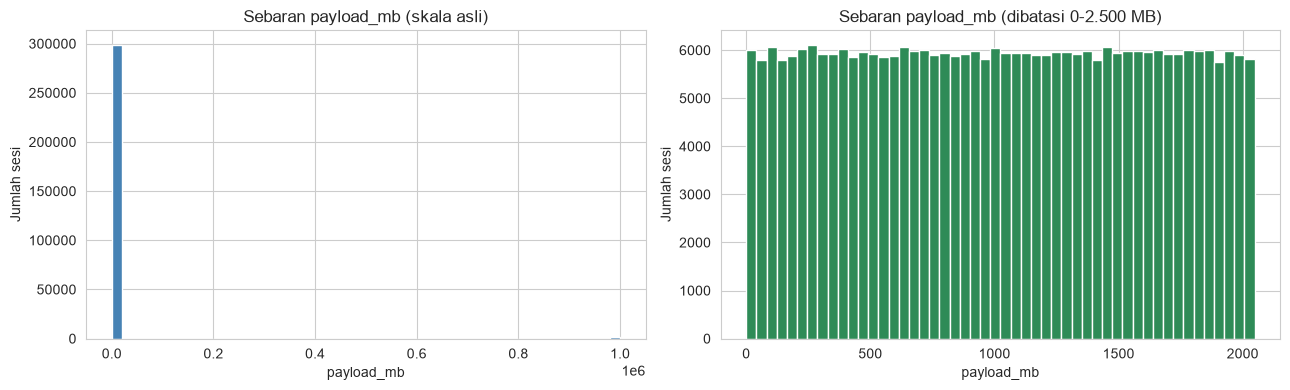

In [9]:
# Visualisasi sebaran payload_mb
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df_usage['payload_mb'], bins=50, color='steelblue')
axes[0].set_title('Sebaran payload_mb (skala asli)')
axes[0].set_xlabel('payload_mb')
axes[0].set_ylabel('Jumlah sesi')

# Dibatasi 0-2500 MB agar sebaran nilai wajar terlihat jelas
payload_wajar = df_usage[(df_usage['payload_mb'] >= 0) & (df_usage['payload_mb'] <= 2500)]
axes[1].hist(payload_wajar['payload_mb'], bins=50, color='seagreen')
axes[1].set_title('Sebaran payload_mb (dibatasi 0-2.500 MB)')
axes[1].set_xlabel('payload_mb')
axes[1].set_ylabel('Jumlah sesi')

plt.tight_layout()
plt.show()

> ### 📌 INSIGHT
>
> **Melakukan apa:** Menampilkan statistik deskriptif dan sebaran kolom `payload_mb`.
>
> **Outputnya apa:** Nilai minimumnya **-150,5 MB** dan maksimumnya **999.999,9 MB**, sementara nilai rata-ratanya 6.159 MB. Pemeriksaan nilai unik menunjukkan bahwa **seluruh 1.469 sesi negatif bernilai sama persis, yaitu -150,5**, dan nilai wajar tertinggi hanya **2.047,98 MB** — tidak ada satu pun nilai di antara 2.047,98 dan 999.999,9. Grafik kiri hampir kosong karena skalanya tertarik oleh nilai ekstrem tersebut.
>
> **Alasannya apa:** Dua temuan ini **tidak wajar**. Pemakaian data tidak mungkin bernilai negatif, dan 999.999,9 MB setara **hampir 1 Terabyte dalam satu sesi**. Fakta bahwa nilainya **selalu sama persis** menunjukkan keduanya bukan sebaran alami, melainkan **nilai isian (*placeholder*) dari sistem**. Keduanya akan **dihapus** pada tahap cleaning: nilai negatif mustahil secara definisi, sedangkan nilai 999.999,9 diperlakukan sebagai nilai isian karena identik pada 1.544 baris sekaligus dan terpisah sangat jauh dari sebaran normal.

## 6.5 Eksplorasi Kolom `network_type`

Kolom `network_type` mencatat jenis jaringan yang dipakai pada setiap sesi. Nilainya diperiksa untuk memastikan penulisannya sudah konsisten.

In [10]:
print("=== Penulisan network_type pada data mentah ===")
print(df_usage['network_type'].value_counts())
print()
print(f"Jumlah variasi penulisan: {df_usage['network_type'].nunique()}")

=== Penulisan network_type pada data mentah ===
network_type
4G        89981
LTE       44884
4G LTE    30339
5G        30075
4g        29833
WCDMA     15225
3G        15076
NR        14941
HSDPA     14905
5g        14741
Name: count, dtype: int64

Jumlah variasi penulisan: 10


> ### 📌 INSIGHT
>
> **Melakukan apa:** Menampilkan seluruh variasi penulisan pada kolom `network_type`.
>
> **Outputnya apa:** Ditemukan **10 variasi penulisan**, padahal jenis jaringan yang ada hanya **3**: `4G`, `4g`, `4G LTE`, `LTE` (semuanya 4G); `5G`, `5g`, `NR` (semuanya 5G); serta `3G`, `WCDMA`, `HSDPA` (semuanya 3G).
>
> **Alasannya apa:** Perbedaan ini terjadi karena setiap tower BTS mencatat dengan istilah yang berbeda — sebagian memakai **istilah komersial** (3G/4G/5G), sebagian memakai **istilah teknis** (WCDMA/HSDPA untuk 3G, LTE untuk 4G, NR untuk 5G), dan sebagian lagi berbeda hanya pada **huruf besar/kecil**. Ketiganya merujuk pada jaringan fisik yang sama. Kolom ini akan **diseragamkan menjadi 3 kategori** agar perhitungan tidak terpecah.

## 6.6 Eksplorasi Kolom `used_imei`

Kolom `used_imei` mencatat perangkat yang benar-benar dipakai pada setiap sesi. Karena kolom inilah yang menjadi inti dari pertanyaan utama, pemeriksaannya dilakukan lebih dalam: berapa banyak perangkat yang berbeda, dan apakah ada nilai yang muncul secara tidak wajar.

In [11]:
print(f"Jumlah IMEI berbeda pada df_usage : {df_usage['used_imei'].nunique():,}")
print(f"Jumlah total sesi                 : {len(df_usage):,}")
print()

frekuensi_imei = df_usage['used_imei'].value_counts()

print("=== 10 IMEI yang paling sering muncul ===")
display(frekuensi_imei.head(10))

print("=== Perbandingan ===")
print(f"IMEI terbanyak muncul       : {frekuensi_imei.iloc[0]:,} kali")
print(f"IMEI terbanyak KEDUA muncul : {frekuensi_imei.iloc[1]:,} kali")
print(f"Median kemunculan IMEI lain : {frekuensi_imei.iloc[1:].median():,.0f} kali")

Jumlah IMEI berbeda pada df_usage : 18,364
Jumlah total sesi                 : 300,000

=== 10 IMEI yang paling sering muncul ===


used_imei
350000009999999    18114
350000000001219       50
350000000001802       48
350000000005199       47
350000000005704       45
350000000002920       45
350000000006848       45
350000000001949       44
350000000003678       44
350000000002015       43
Name: count, dtype: int64

=== Perbandingan ===
IMEI terbanyak muncul       : 18,114 kali
IMEI terbanyak KEDUA muncul : 50 kali
Median kemunculan IMEI lain : 10 kali


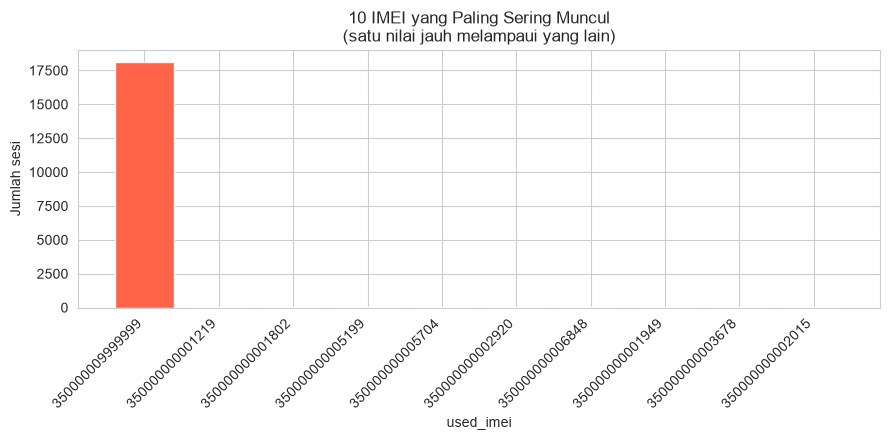

In [12]:
# Visualisasi 10 IMEI paling sering muncul
fig, ax = plt.subplots(figsize=(9, 4.5))

sepuluh_teratas = frekuensi_imei.head(10)
warna = ['tomato'] + ['steelblue'] * 9   # IMEI teratas diberi warna berbeda

ax.bar(range(len(sepuluh_teratas)), sepuluh_teratas.values, color=warna)
ax.set_xticks(range(len(sepuluh_teratas)))
ax.set_xticklabels(sepuluh_teratas.index, rotation=45, ha='right')
ax.set_title('10 IMEI yang Paling Sering Muncul\n(satu nilai jauh melampaui yang lain)')
ax.set_ylabel('Jumlah sesi')
ax.set_xlabel('used_imei')

plt.tight_layout()
plt.show()

> ### 📌 INSIGHT
>
> **Melakukan :** Menghitung frekuensi kemunculan setiap `used_imei` dan menampilkan 10 nilai teratas.
>
> **Output :** Terdapat **18.364 IMEI berbeda** pada 300.000 sesi. Namun ditemukan **satu nilai IMEI yang sangat janggal**, yaitu **`350000009999999` yang muncul sebanyak 18.114 kali**. Sebagai pembanding, IMEI terbanyak kedua hanya muncul **50 kali**, dan IMEI pada umumnya hanya muncul sekitar **10 kali**. Grafik menunjukkan satu batang merah yang menjulang jauh melampaui batang lainnya.
>
> **Alasan :** Satu perangkat fisik **sangat tidak wajar** apabila dipakai 18.114 kali sementara perangkat lain hanya sekitar 10 kali. Ditambah lagi, pola angkanya (`35000000` diikuti `9999999`) merupakan ciri khas **nilai isian bawaan sistem**, bukan pola nomor seri perangkat pada umumnya. Nilai ini akan **ditandai** pada tahap cleaning dan menjadi **fokus utama** analisis, karena diduga kuat inilah penyebab tingginya angka IMEI mismatch.

## 6.7 Eksplorasi Kolom `nik_kk_status`

Kolom ini mencatat status verifikasi NIK/KK pelanggan saat registrasi kartu prabayar, sesuai regulasi Kominfo.

In [13]:
print("=== Nilai pada nik_kk_status (termasuk yang kosong) ===")
print(df_subs['nik_kk_status'].value_counts(dropna=False))
print()
print(f"Jumlah kategori (selain kosong): {df_subs['nik_kk_status'].nunique()}")

=== Nilai pada nik_kk_status (termasuk yang kosong) ===
nik_kk_status
Valid    29798
NaN       5202
Name: count, dtype: int64

Jumlah kategori (selain kosong): 1


> ### 📌 INSIGHT
>
> **Melakukan :** Menampilkan seluruh nilai pada kolom `nik_kk_status`, termasuk nilai yang kosong.
>
> **Output:** Kolom ini ternyata **hanya memiliki satu kategori terisi**, yaitu `Valid` sebanyak **29.798 baris (85,14%)**, sisanya **5.202 baris kosong (14,86%)**. **Tidak ada kategori `Tidak Valid`** sama sekali.
>
> **Alasan:** Karena tidak ada kategori 'Tidak Valid', maka sinyal ketidakpatuhan registrasi pada data ini **direpresentasikan oleh kekosongan itu sendiri**. Nilai kosong akan diberi label **`'Missing'`** secara eksplisit agar tetap terhitung sebagai kategori tersendiri saat dianalisis. Perlu dicatat bahwa analisis atas kolom ini sesungguhnya merupakan analisis **tingkat kelengkapan data**, bukan tingkat validitas.

## 6.8 Eksplorasi Kolom Tanggal

Kolom `session_time` dan `activation_date` diperiksa rentang waktunya, untuk memastikan tidak ada tanggal yang mustahil.

In [14]:
# Konversi sementara hanya untuk keperluan pemeriksaan
session_time_cek = pd.to_datetime(df_usage['session_time'])
activation_cek = pd.to_datetime(df_subs['activation_date'])

print("=== Rentang waktu sesi pemakaian internet (session_time) ===")
print(f"Paling awal  : {session_time_cek.min()}")
print(f"Paling akhir : {session_time_cek.max()}")
print()

print("=== Rentang tanggal aktivasi kartu (activation_date) ===")
print(f"Paling awal  : {activation_cek.min()}")
print(f"Paling akhir : {activation_cek.max()}")
print()

sesi_sebelum_aktivasi_paling_awal = (session_time_cek < activation_cek.min()).sum()
print(f"Sesi yang terjadi SEBELUM tanggal aktivasi paling awal: {sesi_sebelum_aktivasi_paling_awal:,} sesi")

=== Rentang waktu sesi pemakaian internet (session_time) ===
Paling awal  : 2022-12-23 00:00:00
Paling akhir : 2023-12-25 22:17:00

=== Rentang tanggal aktivasi kartu (activation_date) ===
Paling awal  : 2023-01-01 00:00:00
Paling akhir : 2023-10-27 00:00:00

Sesi yang terjadi SEBELUM tanggal aktivasi paling awal: 195 sesi


> ### 📌 INSIGHT
>
> **Melakukan :** Memeriksa rentang waktu pada kolom `session_time` dan `activation_date`.
>
> **Output:** Sesi pemakaian internet tercatat mulai **2022-12-23** hingga **2023-12-25**, sedangkan aktivasi kartu paling awal baru terjadi pada **2023-01-01**. Artinya terdapat **195 sesi yang tercatat terjadi sebelum kartu paling awal pun diaktifkan**.
>
> **Alasan :** Sesi internet **tidak mungkin** terjadi sebelum kartunya aktif. Temuan ini merupakan indikasi awal adanya ***logical error*** pada sistem pencatatan. Jumlah pastinya akan dihitung per pelanggan pada tahap analisis, setelah kedua tabel digabungkan, sehingga setiap sesi dapat dibandingkan dengan tanggal aktivasi nomornya masing-masing.

## 6.9 Pemeriksaan Hubungan Antar Tabel

Sebelum ketiga tabel digabungkan, perlu dipastikan bahwa kolom penghubungnya benar-benar cocok. Apabila ada nilai yang tidak ditemukan pasangannya, proses `merge` akan menghasilkan data kosong.

In [15]:
# Apakah semua msisdn di df_usage ada di df_subs?
msisdn_usage = set(df_usage['msisdn'])
msisdn_subs = set(df_subs['msisdn'])

print("=== Hubungan df_usage <-> df_subs (lewat msisdn) ===")
print(f"msisdn di df_usage tapi TIDAK ADA di df_subs : {len(msisdn_usage - msisdn_subs):,}")
print(f"Pelanggan di df_subs yang TIDAK punya sesi    : {len(msisdn_subs - msisdn_usage):,}")
print()

# Apakah semua package_code di df_usage ada di df_package?
paket_usage = set(df_usage['package_code'])
paket_ref = set(df_package['package_code'])

print("=== Hubungan df_usage <-> df_package (lewat package_code) ===")
print(f"package_code di df_usage tapi TIDAK ADA di df_package : {len(paket_usage - paket_ref)}")
print(f"package_code di df_package yang TIDAK PERNAH dipakai   : {len(paket_ref - paket_usage)}")
print()

print("=== Jumlah sesi per pelanggan ===")
sesi_per_pelanggan = df_usage['msisdn'].value_counts()
print(f"Paling sedikit : {sesi_per_pelanggan.min()} sesi")
print(f"Median         : {sesi_per_pelanggan.median():.0f} sesi")
print(f"Paling banyak  : {sesi_per_pelanggan.max()} sesi")

=== Hubungan df_usage <-> df_subs (lewat msisdn) ===
msisdn di df_usage tapi TIDAK ADA di df_subs : 0
Pelanggan di df_subs yang TIDAK punya sesi    : 9

=== Hubungan df_usage <-> df_package (lewat package_code) ===
package_code di df_usage tapi TIDAK ADA di df_package : 0
package_code di df_package yang TIDAK PERNAH dipakai   : 0

=== Jumlah sesi per pelanggan ===
Paling sedikit : 1 sesi
Median         : 8 sesi
Paling banyak  : 23 sesi


> ### 📌 INSIGHT
>
> **Melakukan apa:** Memeriksa kecocokan kolom penghubung antar tabel — yaitu memastikan setiap nilai penghubung punya pasangan.
>
> **Output :** **Seluruh `msisdn` pada `df_usage` ditemukan di `df_subs`** (0 nomor yatim), dan **seluruh `package_code` cocok dua arah** — 10 paket terdaftar dan semuanya terpakai. Hanya terdapat **9 pelanggan yang tidak memiliki sesi pemakaian sama sekali**. Setiap pelanggan memiliki antara 1 sampai 23 sesi, dengan median 8 sesi.
>
> **Alasan :** Hubungan antar tabel **sudah bersih**, sehingga proses `merge` dapat dilakukan dengan aman tanpa risiko kehilangan data. Penggabungan akan memakai metode `how='left'` dengan `df_usage` sebagai tabel utama, karena analisis ini bekerja pada **tingkat sesi**. Ke-9 pelanggan tanpa sesi tidak akan ikut masuk, dan hal tersebut memang sesuai kebutuhan analisis.

## 6.10 Ringkasan Temuan EDA

| No | Temuan | Lokasi | Jumlah | Tindakan pada Cleaning |
|---|---|---|---|---|
| 1 | Kolom tanggal masih bertipe teks | `df_usage`, `df_subs` | 2 kolom | Konversi ke tipe tanggal |
| 2 | `nik_kk_status` kosong | `df_subs` | 5.202 (14,86%) | Diberi label `'Missing'` |
| 3 | `registered_imei` kosong | `df_subs` | 24.470 (69,91%) | Dibiarkan — penanda pelanggan non-bundling |
| 4 | Nomor HP terdaftar ganda | `df_subs` | 1 nomor | Disisakan aktivasi paling awal |
| 5 | Penulisan `network_type` tidak konsisten | `df_usage` | 10 variasi → 3 | Diseragamkan |
| 6 | `payload_mb` bernilai negatif | `df_usage` | 1.469 (0,49%) | **Dihapus** |
| 7 | `payload_mb` bernilai ekstrem (±1 TB) | `df_usage` | 1.544 (0,51%) | **Dihapus** |
| 8 | IMEI janggal `350000009999999` | `df_usage` | 18.114 sesi | Ditandai → fokus analisis |
| 9 | Sesi sebelum aktivasi kartu | gabungan | dihitung nanti | Ditandai sebagai *logical error* |

Temuan nomor **8** merupakan temuan yang paling penting, karena berkaitan langsung dengan pertanyaan utama project ini.

---
# 7. Data Cleaning

Berdasarkan temuan pada tahap EDA, dilakukan pembersihan data secara berurutan. Setiap langkah disertai **alasan** yang mendasarinya, baik berdasarkan ***domain knowledge*** (pengetahuan tentang konteks bisnis dan teknis) maupun ***bukti statistik*** (angka yang diperoleh dari data itu sendiri).

Urutan pembersihan:

1. Perbaikan tipe data
2. Penanganan nomor HP ganda
3. Penanganan *missing value*
4. Penyeragaman `network_type`
5. Penghapusan `payload_mb` negatif
6. Penghapusan `payload_mb` ekstrem
7. Penggabungan ketiga tabel

## 7.1 Perbaikan Tipe Data

Selanjutnya dilakukan perbaikan tipe data pada kolom tanggal. Kolom `session_time` dan `activation_date` masih berupa teks, sehingga belum dapat dibandingkan satu sama lain. Padahal perbandingan tersebut dibutuhkan untuk menemukan sesi yang terjadi sebelum kartu diaktifkan.

In [16]:
df_usage['session_time'] = pd.to_datetime(df_usage['session_time'])
df_subs['activation_date'] = pd.to_datetime(df_subs['activation_date'])

print("Tipe data setelah diperbaiki:")
print(f"session_time    : {df_usage['session_time'].dtype}")
print(f"activation_date : {df_subs['activation_date'].dtype}")
print()
print("Contoh perbandingan tanggal sekarang sudah bisa dilakukan:")
print(df_usage['session_time'].min() < df_subs['activation_date'].min())

Tipe data setelah diperbaiki:
session_time    : datetime64[us]
activation_date : datetime64[us]

Contoh perbandingan tanggal sekarang sudah bisa dilakukan:
True


> ### 📌 INSIGHT
>
> **Melakukan :** Mengubah kolom `session_time` dan `activation_date` dari tipe teks (`object`) menjadi tipe tanggal (`datetime64`).
>
> **Output :** Kedua kolom berhasil dikonversi, dan perbandingan antar tanggal kini dapat dilakukan.
>
> **Alasan :** Alasannya bersifat **teknis**: selama masih berupa teks, Python membandingkan tanggal secara **alfabetis**, bukan secara kronologis, sehingga hasilnya keliru. Kolom `msisdn` dan IMEI sendiri **sengaja dibiarkan sebagai teks** karena keduanya adalah kode identitas — bukan nilai yang perlu dihitung — dan sudah dibaca sebagai teks sejak awal agar angka nol di depan tidak hilang.

## 7.2 Penanganan Nomor HP Ganda

Pada tahap EDA ditemukan 1 nomor HP yang terdaftar dua kali dengan tanggal aktivasi berbeda. Baris ini perlu disisakan satu saja sebelum tabel digabungkan.

In [17]:
jumlah_sebelum = len(df_subs)

# Diurutkan berdasarkan tanggal aktivasi, lalu disisakan baris pertama (aktivasi paling awal)
df_subs_clean = df_subs.sort_values('activation_date').drop_duplicates(subset='msisdn', keep='first').copy()

print(f"Jumlah baris sebelum : {jumlah_sebelum:,}")
print(f"Jumlah baris sesudah : {len(df_subs_clean):,}")
print(f"Berkurang            : {jumlah_sebelum - len(df_subs_clean)} baris")
print()
print(f"Sisa nomor HP ganda  : {df_subs_clean['msisdn'].duplicated().sum()}")

Jumlah baris sebelum : 35,000
Jumlah baris sesudah : 34,999
Berkurang            : 1 baris

Sisa nomor HP ganda  : 0


> ### 📌 INSIGHT
>
> **Melakukan :** Menghapus baris duplikat pada kolom `msisdn` dengan menyisakan baris yang tanggal aktivasinya **paling awal**.
>
> **Output :** Jumlah baris `df_subs` berkurang dari **35.000 menjadi 34.999**, dan tidak ada lagi nomor HP yang terdaftar ganda.
>
> **Alasan :** Alasannya berdasarkan ***domain knowledge***: satu nomor HP hanya dapat memiliki **satu** tanggal aktivasi yang sah, dan yang berlaku adalah **aktivasi pertama** — saat nomor tersebut benar-benar mulai aktif. Selain itu, alasan **teknis**: apabila nomor ganda ini dibiarkan, proses `merge` akan menggandakan seluruh sesi milik nomor tersebut sehingga jumlah baris membengkak dan perhitungan menjadi keliru.

## 7.3 Penanganan *Missing Value*

Terdapat dua kolom dengan nilai kosong, dan keduanya **ditangani secara berbeda** karena maknanya memang berbeda.

### Kolom penanda yang akan dibuat: `is_bundling_customer`

Sebelum masuk ke kodenya, berikut penjelasan kolom penanda yang akan dibuat.

**`is_bundling_customer`** — penanda apakah seorang pelanggan merupakan peserta program Device Bundling.

| Hal | Penjelasan |
|---|---|
| **Tipe nilai** | *Boolean*, yaitu kolom yang isinya hanya `True` (benar) atau `False` (salah) |
| **Cara menentukan** | `registered_imei` **terisi** → `True` · `registered_imei` **kosong** → `False` |
| **Arti `True`** | Pelanggan mendaftarkan perangkatnya saat pembelian, berarti peserta program bundling |
| **Arti `False`** | Tidak ada perangkat yang didaftarkan, berarti pelanggan biasa |
| **Kenapa dibuat** | Agar peserta bundling bisa dipisahkan dari pelanggan biasa. Hanya peserta bundling yang bisa diperiksa kecocokan IMEI-nya, karena hanya mereka yang memiliki `registered_imei` sebagai pembanding |

Kolom *boolean* dipilih karena mudah dihitung — cukup dijumlahkan dengan `.sum()`, maka `True` akan terhitung sebagai 1 dan `False` sebagai 0.

In [18]:
# nik_kk_status: nilai kosong diberi label 'Missing' agar tetap terhitung
df_subs_clean['nik_kk_status'] = df_subs_clean['nik_kk_status'].fillna('Missing')

# registered_imei: dibiarkan kosong, justru dipakai untuk menandai pelanggan bundling
df_subs_clean['is_bundling_customer'] = df_subs_clean['registered_imei'].notna()

print("=== nik_kk_status setelah diberi label ===")
print(df_subs_clean['nik_kk_status'].value_counts())
print()
print("=== Penanda pelanggan bundling ===")
print(df_subs_clean['is_bundling_customer'].value_counts())
print()
print(f"Sisa nilai kosong di nik_kk_status : {df_subs_clean['nik_kk_status'].isna().sum()}")

=== nik_kk_status setelah diberi label ===
nik_kk_status
Valid      29797
Missing     5202
Name: count, dtype: int64

=== Penanda pelanggan bundling ===
is_bundling_customer
False    24469
True     10530
Name: count, dtype: int64

Sisa nilai kosong di nik_kk_status : 0


> ### 📌 INSIGHT
>
> **Melakukan :** Mengisi nilai kosong pada `nik_kk_status` dengan label `'Missing'`, serta membuat kolom penanda `is_bundling_customer` dari kolom `registered_imei`.
>
> **Output :** Kolom `nik_kk_status` kini berisi **29.797 `Valid`** dan **5.202 `Missing`**, tanpa nilai kosong tersisa. Penanda `is_bundling_customer` menghasilkan **10.530 pelanggan bundling** dan 24.469 pelanggan non-bundling.
>
> **Alasan :** Kedua kolom ditangani berbeda karena maknanya berbeda. Pada `nik_kk_status`, kekosongan menunjukkan **status registrasi yang tidak tersedia** dan justru ingin dihitung — apabila dihapus, buktinya ikut hilang; apabila diisi dengan `Valid`, datanya menjadi bohong. Karena itu diberi label eksplisit agar tetap terlihat. Sementara pada `registered_imei`, kekosongan bersifat **wajar dan disengaja** — pelanggan non-bundling memang tidak mendaftarkan perangkat. Karena itu tidak diisi, melainkan **dimanfaatkan** sebagai penanda siapa peserta program bundling.

> ⚠️ **Catatan penting untuk interpretasi.**
> Kolom `is_bundling_customer` berarti **"pelanggan yang memiliki IMEI terdaftar"**, bukan "pelanggan yang membeli paket bundling". Keduanya tidak sama.
> Pada analisis selanjutnya, istilah yang dipakai adalah **pelanggan dengan IMEI terdaftar**, agar tidak menimbulkan kesimpulan yang keliru.

## 7.4 Penyeragaman `network_type`

Pada tahap EDA ditemukan 10 variasi penulisan untuk 3 jenis jaringan. Sebelum diseragamkan, kondisi awalnya disimpan terlebih dahulu agar dapat dibandingkan secara visual pada tahap analisis.

In [19]:
# Kondisi SEBELUM disimpan lebih dulu, agar bisa dibandingkan nanti
network_type_sebelum = df_usage['network_type'].value_counts()

# Pemetaan 10 variasi penulisan menjadi 3 kategori
peta_network = {
    '4G': '4G', '4g': '4G', '4G LTE': '4G', 'LTE': '4G',
    '5G': '5G', '5g': '5G', 'NR': '5G',
    '3G': '3G', 'WCDMA': '3G', 'HSDPA': '3G'
}

df_usage['network_type'] = df_usage['network_type'].map(peta_network)

print("=== SEBELUM diseragamkan ===")
print(network_type_sebelum)
print()
print("=== SESUDAH diseragamkan ===")
print(df_usage['network_type'].value_counts())
print()
print(f"Nilai kosong setelah pemetaan: {df_usage['network_type'].isna().sum()} (harus 0)")

=== SEBELUM diseragamkan ===
network_type
4G        89981
LTE       44884
4G LTE    30339
5G        30075
4g        29833
WCDMA     15225
3G        15076
NR        14941
HSDPA     14905
5g        14741
Name: count, dtype: int64

=== SESUDAH diseragamkan ===
network_type
4G    195037
5G     59757
3G     45206
Name: count, dtype: int64

Nilai kosong setelah pemetaan: 0 (harus 0)


> ### 📌 INSIGHT
>
> **Melakukan :** Menyeragamkan 10 variasi penulisan `network_type` menjadi 3 kategori menggunakan `.map()` dengan kamus pemetaan.
>
> **Output :** Penulisan berhasil disederhanakan dari **10 variasi menjadi 3 kategori**: **4G sebanyak 195.037 sesi**, **5G sebanyak 59.757 sesi**, dan **3G sebanyak 45.206 sesi**. Tidak ada nilai kosong yang tersisa, artinya seluruh variasi berhasil terpetakan.
>
> **Alasan :** Alasannya berdasarkan ***domain knowledge*** telekomunikasi: `WCDMA` dan `HSDPA` adalah nama teknis dari jaringan **3G**, `LTE` adalah nama teknis dari **4G**, dan `NR` (*New Radio*) adalah nama teknis dari **5G**. Ketiganya merujuk pada jaringan fisik yang sama, hanya berbeda istilah. Apabila tidak diseragamkan, jumlah sesi 4G akan terpecah menjadi empat kelompok terpisah sehingga tidak dapat dijumlahkan dengan benar.

## 7.5 Penghapusan `payload_mb` Negatif

Pada tahap EDA ditemukan sesi dengan pemakaian data bernilai negatif. Jumlah dan karakteristiknya diperiksa kembali sebelum dihapus.

In [20]:
jumlah_negatif = (df_usage['payload_mb'] < 0).sum()
persen_negatif = jumlah_negatif / len(df_usage) * 100

print(f"Sesi dengan payload_mb negatif : {jumlah_negatif:,} dari {len(df_usage):,} sesi ({persen_negatif:.2f}%)")
print(f"Nilai unik pada sesi negatif   : {df_usage.loc[df_usage['payload_mb'] < 0, 'payload_mb'].unique()}")
print()

display(df_usage[df_usage['payload_mb'] < 0][['session_id', 'msisdn', 'session_time', 'payload_mb']].head())

Sesi dengan payload_mb negatif : 1,469 dari 300,000 sesi (0.49%)
Nilai unik pada sesi negatif   : [-150.5]



,session_id,msisdn,session_time,payload_mb
52,CDR000000053,081248278361,2023-09-07 16:04:00,-150.5
144,CDR000000145,081176984500,2023-10-11 10:49:00,-150.5
270,CDR000000271,085224424321,2023-08-06 00:24:00,-150.5
280,CDR000000281,085221667055,2023-09-06 02:27:00,-150.5
300,CDR000000301,081272847111,2023-04-21 21:21:00,-150.5


In [21]:
# Menghapus baris dengan payload negatif
df_clean = df_usage[df_usage['payload_mb'] >= 0].copy()

print(f"Jumlah baris sebelum : {len(df_usage):,}")
print(f"Jumlah baris sesudah : {len(df_clean):,}")
print(f"Terhapus             : {len(df_usage) - len(df_clean):,} baris ({persen_negatif:.2f}%)")

Jumlah baris sebelum : 300,000
Jumlah baris sesudah : 298,531
Terhapus             : 1,469 baris (0.49%)


> ### 📌 INSIGHT
>
> **Melakukan :** Menghapus seluruh baris yang nilai `payload_mb`-nya di bawah 0.
>
> **Output :** Terhapus **1.469 baris (0,49%)** dari data, sehingga jumlah baris berkurang dari **300.000 menjadi 298.531**. Seluruh baris yang terhapus bernilai **sama persis, yaitu -150,5**.
>
> **Alasan :** Alasannya berdasarkan ***domain knowledge***: `payload_mb` menghitung jumlah data yang **dipakai** dalam satu sesi, dan nilainya hanya mungkin berada pada rentang 0 ke atas — tidak ada skenario nyata di mana perangkat 'memakai data sejumlah minus 150 MB'. Ditambah **bukti statistik**: fakta bahwa seluruh 1.469 baris bernilai **identik** menunjukkan ini bukan angka pemakaian yang sesungguhnya, melainkan **nilai isian bawaan dari sistem**. Karena nilainya mustahil secara fisik dan porsinya sangat kecil (di bawah 0,5%), baris tersebut dihapus.

## 7.6 Penghapusan `payload_mb` Ekstrem

Selain nilai negatif, ditemukan juga nilai yang sangat besar. Untuk menentukan batas mana yang dianggap tidak wajar, akan diuji **dua kondisi** yang berbeda, lalu dipilih **satu** yang paling tepat untuk dipakai.

**Kondisi 1 — Pendekatan statistik (metode IQR).** Batas atas kewajaran dihitung dari sebaran datanya sendiri menggunakan rumus `Q3 + 1.5 × IQR`.

**Kondisi 2 — Pendekatan logika (*domain knowledge*).** Nilai `999999.9` MB setara dengan sekitar **976 GB atau hampir 1 Terabyte dalam satu sesi**, dan nilai yang sama persis itu berulang pada 1.544 baris.

Perhitungan IQR dilakukan **setelah** payload negatif dihapus, agar nilai mustahil tersebut tidak ikut menggeser posisi Q1 dan Q3.

In [22]:
# --- KONDISI 1: pendekatan statistik (IQR) ---
Q1 = df_clean['payload_mb'].quantile(0.25)
Q3 = df_clean['payload_mb'].quantile(0.75)
IQR = Q3 - Q1
batas_atas = Q3 + 1.5 * IQR
batas_bawah = Q1 - 1.5 * IQR

kondisi_1 = df_clean['payload_mb'] > batas_atas

print("=== KONDISI 1: Metode IQR (statistik) ===")
print(f"Q1 (kuartil 1)  : {Q1:,.2f} MB")
print(f"Q3 (kuartil 3)  : {Q3:,.2f} MB")
print(f"IQR (Q3 - Q1)   : {IQR:,.2f} MB")
print(f"Batas atas      : {batas_atas:,.2f} MB")
print(f"Batas bawah     : {batas_bawah:,.2f} MB")
print(f"--> Sesi yang tertangkap: {kondisi_1.sum():,} sesi")
print()

# --- KONDISI 2: pendekatan logika (domain knowledge) ---
kondisi_2 = df_clean['payload_mb'] == 999999.9

print("=== KONDISI 2: Nilai isian 999.999,9 MB (logika) ===")
print(f"999.999,9 MB setara dengan {999999.9/1024:,.1f} GB atau {999999.9/1024/1024:.2f} TB dalam SATU sesi")
print(f"--> Sesi yang tertangkap: {kondisi_2.sum():,} sesi")

=== KONDISI 1: Metode IQR (statistik) ===
Q1 (kuartil 1)  : 513.87 MB
Q3 (kuartil 3)  : 1,543.55 MB
IQR (Q3 - Q1)   : 1,029.68 MB
Batas atas      : 3,088.08 MB
Batas bawah     : -1,030.66 MB
--> Sesi yang tertangkap: 1,544 sesi

=== KONDISI 2: Nilai isian 999.999,9 MB (logika) ===
999.999,9 MB setara dengan 976.6 GB atau 0.95 TB dalam SATU sesi
--> Sesi yang tertangkap: 1,544 sesi


In [23]:
# Membandingkan kedua kondisi: apakah menangkap baris yang sama?
print("=== PERBANDINGAN KEDUA KONDISI ===")
print(f"Kondisi 1 (IQR)        : {kondisi_1.sum():,} sesi")
print(f"Kondisi 2 (nilai 999999.9): {kondisi_2.sum():,} sesi")
print(f"Tertangkap KEDUANYA    : {(kondisi_1 & kondisi_2).sum():,} sesi")
print(f"Hanya kondisi 1        : {(kondisi_1 & ~kondisi_2).sum():,} sesi")
print(f"Hanya kondisi 2        : {(~kondisi_1 & kondisi_2).sum():,} sesi")
print()

nilai_wajar_tertinggi = df_clean.loc[~kondisi_1, 'payload_mb'].max()
print(f"Nilai payload WAJAR tertinggi        : {nilai_wajar_tertinggi:,.2f} MB")
print(f"Nilai payload TIDAK WAJAR terendah   : {df_clean.loc[kondisi_1, 'payload_mb'].min():,.2f} MB")
print()
print("Tidak ada satu pun nilai di antara kedua angka tersebut -> keduanya benar-benar terpisah.")

=== PERBANDINGAN KEDUA KONDISI ===
Kondisi 1 (IQR)        : 1,544 sesi
Kondisi 2 (nilai 999999.9): 1,544 sesi
Tertangkap KEDUANYA    : 1,544 sesi
Hanya kondisi 1        : 0 sesi
Hanya kondisi 2        : 0 sesi

Nilai payload WAJAR tertinggi        : 2,047.98 MB
Nilai payload TIDAK WAJAR terendah   : 999,999.90 MB

Tidak ada satu pun nilai di antara kedua angka tersebut -> keduanya benar-benar terpisah.


In [24]:
# Kondisi 1 (IQR) dipilih, lalu baris tersebut dihapus
jumlah_sebelum_outlier = len(df_clean)
df_clean = df_clean[df_clean['payload_mb'] <= batas_atas].copy()

print(f"Jumlah baris sebelum : {jumlah_sebelum_outlier:,}")
print(f"Jumlah baris sesudah : {len(df_clean):,}")
print(f"Terhapus             : {jumlah_sebelum_outlier - len(df_clean):,} baris")
print()
print("=== Statistik payload_mb setelah dibersihkan ===")
display(df_clean['payload_mb'].describe())

Jumlah baris sebelum : 298,531
Jumlah baris sesudah : 296,987
Terhapus             : 1,544 baris

=== Statistik payload_mb setelah dibersihkan ===


count    296987.000000
mean       1023.495093
std         590.951191
min           0.010000
25%         511.205000
50%        1023.720000
75%        1535.670000
max        2047.980000
Name: payload_mb, dtype: float64

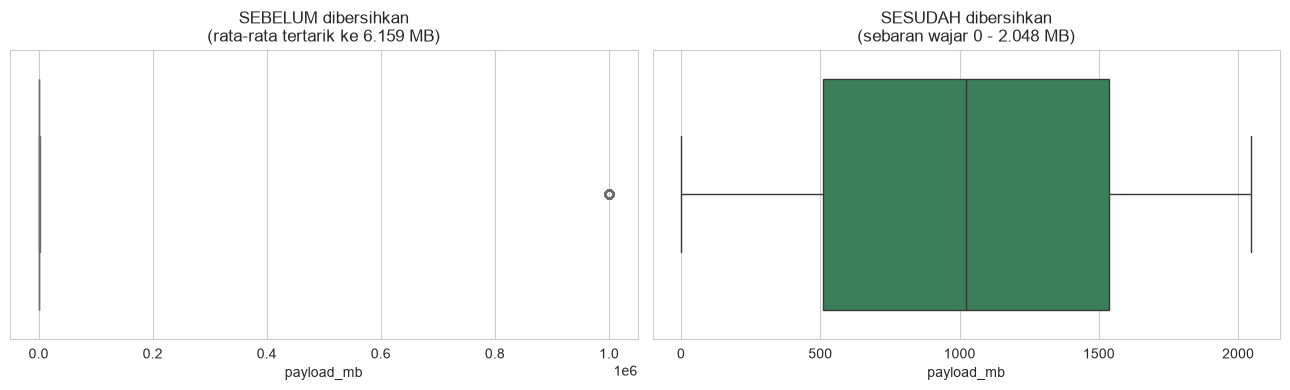

Rata-rata payload SEBELUM dibersihkan : 6,159.14 MB
Rata-rata payload SESUDAH dibersihkan : 1,023.50 MB


In [25]:
# Perbandingan sebaran payload_mb sebelum dan sesudah dibersihkan
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.boxplot(x=df_usage['payload_mb'], ax=axes[0], color='salmon')
axes[0].set_title('SEBELUM dibersihkan\n(rata-rata tertarik ke 6.159 MB)')
axes[0].set_xlabel('payload_mb')

sns.boxplot(x=df_clean['payload_mb'], ax=axes[1], color='seagreen')
axes[1].set_title('SESUDAH dibersihkan\n(sebaran wajar 0 - 2.048 MB)')
axes[1].set_xlabel('payload_mb')

plt.tight_layout()
plt.show()

print(f"Rata-rata payload SEBELUM dibersihkan : {df_usage['payload_mb'].mean():,.2f} MB")
print(f"Rata-rata payload SESUDAH dibersihkan : {df_clean['payload_mb'].mean():,.2f} MB")

> ### 📌 INSIGHT
>
> **Melakukan :** Menguji **dua kondisi** untuk menentukan batas nilai `payload_mb` yang tidak wajar, membandingkan hasil keduanya, lalu menghapus baris yang tertangkap.
>
> **Output :** **Kondisi 1 (IQR)** menghasilkan batas atas **3.088,08 MB** dan menangkap **1.544 sesi**. **Kondisi 2 (nilai 1 TB)** juga menangkap **1.544 sesi**. Perbandingan menunjukkan **keduanya menangkap baris yang sama persis** — tidak ada selisih sama sekali. Nilai wajar tertinggi adalah **2.047,98 MB**, sedangkan nilai tidak wajar terendah adalah **999.999,9 MB**, tanpa satu pun nilai di antaranya. Setelah dihapus, rata-rata pemakaian turun drastis dari **6.159 MB menjadi 1.023 MB**.
>
> **Alasan :** **Kondisi 1 (IQR) yang dipilih**, karena batasnya **dihitung dari sebaran data itu sendiri**, bukan angka yang ditentukan sendiri secara manual — sehingga lebih objektif dan dapat dipertanggungjawabkan. Kondisi 2 tetap berperan penting sebagai **konfirmasi**: kedua pendekatan yang berbeda menghasilkan kesimpulan yang sama persis, sehingga keputusan penghapusan ini kuat. Perlu dicatat bahwa **IQR saja tidak cukup** — batas bawahnya berada di **-1.030,66 MB**, sementara nilai negatif pada data adalah -150,5 MB yang **masih berada di dalam batas tersebut**. Karena itu payload negatif tidak akan tertangkap oleh IQR, dan harus ditangani dengan aturan logika terpisah seperti pada langkah 7.5.

## 7.7 Penggabungan Ketiga Tabel

Setelah seluruh tabel dibersihkan, ketiganya digabungkan menjadi satu tabel agar seluruh informasi yang dibutuhkan tersedia bersama-sama.

Penggabungan menggunakan `how='left'` dengan tabel sesi (`df_clean`) sebagai tabel utama, karena analisis ini bekerja pada **tingkat sesi**. Setiap langkah `merge` diperiksa jumlah barisnya untuk memastikan tidak ada baris yang tergandakan.

In [26]:
baris_sebelum_merge = len(df_clean)

# Menggabungkan informasi pelanggan
df_clean = df_clean.merge(
    df_subs_clean[['msisdn', 'activation_date', 'nik_kk_status', 'registered_imei', 'is_bundling_customer']],
    on='msisdn',
    how='left'
)
print(f"Setelah digabung dengan data pelanggan : {len(df_clean):,} baris (sebelumnya {baris_sebelum_merge:,})")

# Menggabungkan informasi paket
df_clean = df_clean.merge(
    df_package[['package_code', 'package_name', 'price']],
    on='package_code',
    how='left'
)
print(f"Setelah digabung dengan data paket     : {len(df_clean):,} baris")
print()

if len(df_clean) == baris_sebelum_merge:
    print("Jumlah baris TIDAK berubah -> penggabungan berhasil, tidak ada baris yang tergandakan.")
else:
    print("PERINGATAN: jumlah baris berubah, ada indikasi baris tergandakan saat merge.")

print()
print("Kolom pada tabel gabungan:")
print(list(df_clean.columns))

Setelah digabung dengan data pelanggan : 296,987 baris (sebelumnya 296,987)
Setelah digabung dengan data paket     : 296,987 baris

Jumlah baris TIDAK berubah -> penggabungan berhasil, tidak ada baris yang tergandakan.

Kolom pada tabel gabungan:
['session_id', 'msisdn', 'package_code', 'used_imei', 'session_time', 'network_type', 'payload_mb', 'activation_date', 'nik_kk_status', 'registered_imei', 'is_bundling_customer', 'package_name', 'price']


### Tiga kolom penanda yang akan dibuat

Sebelum masuk ke kodenya, berikut penjelasan ketiga kolom penanda yang akan dipakai sepanjang tahap analisis. Ketiganya bertipe *boolean*, yaitu hanya berisi `True` atau `False`.

---

**1. `is_imei_janggal` — apakah sesi ini memakai IMEI janggal?**

| Hal | Penjelasan |
|---|---|
| **Cara menentukan** | `used_imei` sama dengan `350000009999999` → `True` |
| **Arti `True`** | Perangkat pada sesi ini tercatat memakai nilai IMEI yang ditemukan janggal pada tahap EDA |
| **Kenapa dibuat** | Untuk menghitung seberapa sering nilai janggal tersebut muncul, dan pada kelompok pelanggan mana saja |

---

**2. `is_imei_mismatch` — apakah perangkat yang dipakai berbeda dari yang didaftarkan?**

| Hal | Penjelasan |
|---|---|
| **Cara menentukan** | `registered_imei` **terisi** **DAN** `used_imei` **tidak sama dengan** `registered_imei` → `True` |
| **Arti `True`** | Kartu SIM ini sedang dipakai pada perangkat yang berbeda dari yang didaftarkan — indikasi penyalahgunaan |
| **Kenapa dibuat** | Inilah penanda utama yang dipakai untuk menjawab pertanyaan pertama |

> **Kenapa harus ada syarat `registered_imei` terisi?**
> Karena pelanggan biasa (non-bundling) **tidak memiliki pembanding** — mereka memang tidak pernah mendaftarkan perangkat. Tanpa syarat ini, seluruh pelanggan biasa akan ikut tertandai `True` padahal mereka tidak melanggar apa pun. Syarat ini memastikan yang dinilai hanya pelanggan yang memang punya kewajiban mendaftarkan perangkat.

---

**3. `is_logical_error` — apakah sesi ini terjadi sebelum kartunya aktif?**

| Hal | Penjelasan |
|---|---|
| **Cara menentukan** | `session_time` **lebih awal daripada** `activation_date` → `True` |
| **Arti `True`** | Sesi internet tercatat terjadi sebelum kartunya sendiri diaktifkan |
| **Kenapa dibuat** | Kejadian ini mustahil secara logika — kartu yang belum aktif tidak mungkin dipakai internetan. Karena itu penanda ini menunjukkan adanya kekeliruan pada sistem pencatatan |

---

**Contoh cara membacanya:**

| `used_imei` | `registered_imei` | `session_time` | `activation_date` | `is_imei_janggal` | `is_imei_mismatch` | `is_logical_error` |
|---|---|---|---|---|---|---|
| 350000000328759 | 350000000328759 | 2023-03-08 | 2023-03-01 | `False` | `False` | `False` |
| 350000009999999 | 350000000328759 | 2023-03-05 | 2023-03-01 | `True` | `True` | `False` |
| 350000000112233 | *(kosong)* | 2023-02-25 | 2023-03-01 | `False` | `False` | `True` |

Baris pertama normal. Baris kedua memakai IMEI janggal sehingga tertandai pada dua kolom sekaligus. Baris ketiga milik pelanggan biasa — tidak dinilai kecocokan IMEI-nya karena tidak punya pembanding, namun sesinya tercatat lebih awal daripada tanggal aktivasi.

In [27]:
# Membuat kolom penanda untuk keperluan analisis
IMEI_JANGGAL = '350000009999999'

# Penanda 1: sesi yang memakai IMEI janggal
df_clean['is_imei_janggal'] = df_clean['used_imei'] == IMEI_JANGGAL

# Penanda 2: sesi yang IMEI-nya tidak cocok dengan yang didaftarkan
df_clean['is_imei_mismatch'] = (
    df_clean['registered_imei'].notna() &
    (df_clean['used_imei'] != df_clean['registered_imei'])
)

# Penanda 3: sesi yang terjadi sebelum kartu diaktifkan
df_clean['is_logical_error'] = df_clean['session_time'] < df_clean['activation_date']

print("=== Jumlah sesi untuk setiap penanda ===")
print(f"is_imei_janggal   : {df_clean['is_imei_janggal'].sum():,} sesi")
print(f"is_imei_mismatch  : {df_clean['is_imei_mismatch'].sum():,} sesi")
print(f"is_logical_error  : {df_clean['is_logical_error'].sum():,} sesi")
print()
display(df_clean.head())

=== Jumlah sesi untuk setiap penanda ===
is_imei_janggal   : 17,928 sesi
is_imei_mismatch  : 17,928 sesi
is_logical_error  : 11,875 sesi



,session_id,msisdn,package_code,used_imei,session_time,network_type,payload_mb,activation_date,nik_kk_status,registered_imei,is_bundling_customer,package_name,price,is_imei_janggal,is_imei_mismatch,is_logical_error
0,CDR000000001,085254880966,PKG-008,350000000003139,2023-02-12 03:33:00,4G,1153.63,2023-02-09,Valid,NaN,False,Combo Sakti 25GB,100000,False,False,False
1,CDR000000002,085271729455,PKG-009,350000000002881,2023-04-23 21:57:00,4G,224.37,2023-04-02,Valid,NaN,False,Kuota Ketengan YouTube,5000,False,False,False
2,CDR000000004,081225426120,PKG-006,350000000511814,2023-09-26 14:16:00,4G,1538.98,2023-08-03,Valid,350000000511814,True,Internet OMG! 100GB,160000,False,False,False
3,CDR000000005,085267756806,PKG-010,350000000003958,2023-04-28 02:06:00,4G,1722.07,2023-03-10,Missing,NaN,False,Kuota Ketengan TikTok,6000,False,False,False
4,CDR000000006,082161437190,PKG-006,350000000215530,2023-03-16 18:46:00,4G,753.83,2023-01-21,Valid,350000000215530,True,Internet OMG! 100GB,160000,False,False,False


> ### 📌 INSIGHT
>
> **Melakukan :** Menggabungkan ketiga tabel menjadi satu menggunakan `merge`, lalu membuat tiga kolom penanda untuk keperluan analisis.
>
> **Output :** Tabel gabungan berisi **296.987 baris** — jumlahnya **tidak berubah** setelah dua kali `merge`, sehingga dipastikan tidak ada baris yang tergandakan. Ketiga penanda menghasilkan: **17.928 sesi** ber-IMEI janggal, **17.928 sesi** IMEI mismatch, dan **11.875 sesi** *logical error*.
>
> **Alasan :** Penggabungan diperlukan karena informasi yang dibutuhkan tersebar di tiga tabel: IMEI terdaftar ada di tabel pelanggan, IMEI yang dipakai ada di tabel sesi, dan harga paket ada di tabel paket. Metode `how='left'` dipilih agar **seluruh sesi tetap dipertahankan**. Jumlah baris diperiksa setiap kali `merge` karena apabila tabel pelanggan masih memiliki `msisdn` ganda, satu sesi bisa tergandakan menjadi beberapa baris tanpa disadari — itulah alasan penanganan nomor ganda pada langkah 7.2 dilakukan lebih dulu.

## 7.8 Ringkasan Proses Cleaning

| No | Kondisi Sebelum | Tindakan | Kondisi Sesudah | Jenis Alasan |
|---|---|---|---|---|
| 1 | `session_time` & `activation_date` bertipe teks | Konversi ke `datetime` | Dapat dibandingkan | Teknis |
| 2 | 1 nomor HP terdaftar 2× | Disisakan aktivasi paling awal | 34.999 nomor unik | Domain knowledge |
| 3 | `nik_kk_status` kosong 5.202 baris | Diberi label `'Missing'` | 0 nilai kosong | Domain knowledge |
| 4 | `registered_imei` kosong 24.470 baris | Dibiarkan, dijadikan penanda | Jadi `is_bundling_customer` | Domain knowledge |
| 5 | `network_type` 10 variasi | Diseragamkan lewat `.map()` | 3 kategori | Domain knowledge |
| 6 | `payload_mb` negatif 1.469 baris | **Dihapus** | 0 baris negatif | Domain knowledge + statistik |
| 7 | `payload_mb` ekstrem 1.544 baris | **Dihapus** (batas IQR) | Maksimum 2.047,98 MB | Statistik + domain knowledge |
| 8 | Data terpisah di 3 tabel | Digabung 2× `merge` | 1 tabel, 296.987 baris | Teknis |

**Rekonsiliasi jumlah baris:**

```
300.000  baris awal
 -1.469  payload negatif dihapus
 -1.544  payload ekstrem dihapus
--------
296.987  baris siap dianalisis   (berkurang 3.013 baris = 1,00%)
```

Total data yang dibuang hanya **1,00%**, sehingga pembersihan ini **tidak mengubah gambaran keseluruhan data** secara berarti.

In [28]:
# Menyimpan hasil cleaning agar dapat digunakan kembali tanpa mengulang proses
df_clean.to_csv('tsel_clean_final.csv', index=False)

print(f"Data bersih berhasil disimpan sebagai 'tsel_clean_final.csv'")
print(f"Ukuran: {df_clean.shape[0]:,} baris x {df_clean.shape[1]} kolom")

Data bersih berhasil disimpan sebagai 'tsel_clean_final.csv'
Ukuran: 296,987 baris x 16 kolom


### Menyiapkan Data untuk Dashboard

Selain tabel tingkat sesi di atas, disiapkan juga satu tabel **tingkat pelanggan** — satu baris untuk satu nomor HP. Tabel ini diperlukan karena sebagian besar angka kunci pada analisis ini dihitung **per pelanggan**, bukan per sesi.

Tanpa tabel ini, dashboard akan melewatkan **10 pelanggan yang tidak memiliki sesi pemakaian sama sekali**, sehingga angkanya berbeda tipis dari notebook.

In [29]:
# Menghitung kondisi setiap pelanggan berdasarkan seluruh sesi miliknya
ringkasan_sesi = df_clean.groupby('msisdn')[['is_imei_janggal', 'is_imei_mismatch', 'is_logical_error']].max()
ringkasan_sesi = ringkasan_sesi.reset_index()

# Digabung ke tabel pelanggan agar 10 pelanggan tanpa sesi tetap ikut terhitung
df_pelanggan = df_subs_clean[['msisdn', 'activation_date', 'nik_kk_status', 'is_bundling_customer']].copy()
df_pelanggan = df_pelanggan.merge(ringkasan_sesi, on='msisdn', how='left')

# Pelanggan tanpa sesi diisi False, karena mereka tidak punya sesi bermasalah
df_pelanggan['is_imei_janggal'] = df_pelanggan['is_imei_janggal'].fillna(False)
df_pelanggan['is_imei_mismatch'] = df_pelanggan['is_imei_mismatch'].fillna(False)
df_pelanggan['is_logical_error'] = df_pelanggan['is_logical_error'].fillna(False)

df_pelanggan['nik_kk_kosong'] = df_pelanggan['nik_kk_status'] == 'Missing'
df_pelanggan['ada_masalah'] = (
    df_pelanggan['is_imei_mismatch'] |
    df_pelanggan['is_logical_error'] |
    df_pelanggan['nik_kk_kosong']
)

df_pelanggan.to_csv('tableau_pelanggan.csv', index=False)

print(f"Tabel tingkat pelanggan disimpan sebagai 'tableau_pelanggan.csv'")
print(f"Ukuran: {df_pelanggan.shape[0]:,} baris x {df_pelanggan.shape[1]} kolom")
print()
print("=== Angka kunci (harus sama dengan hasil analisis di atas) ===")
print(f"Total pelanggan              : {len(df_pelanggan):,}")
print(f"Pelanggan ber-IMEI terdaftar : {df_pelanggan['is_bundling_customer'].sum():,}")
print(f"Kena IMEI tidak cocok        : {df_pelanggan['is_imei_mismatch'].sum():,}")
print(f"Kena sesi sebelum aktif      : {df_pelanggan['is_logical_error'].sum():,}")
print(f"NIK/KK belum lengkap         : {df_pelanggan['nik_kk_kosong'].sum():,}")
print(f"Ada minimal 1 masalah        : {df_pelanggan['ada_masalah'].sum():,} ({df_pelanggan['ada_masalah'].mean()*100:.2f}%)")

Tabel tingkat pelanggan disimpan sebagai 'tableau_pelanggan.csv'
Ukuran: 34,999 baris x 9 kolom

=== Angka kunci (harus sama dengan hasil analisis di atas) ===
Total pelanggan              : 34,999
Pelanggan ber-IMEI terdaftar : 10,530
Kena IMEI tidak cocok        : 8,641
Kena sesi sebelum aktif      : 10,083
NIK/KK belum lengkap         : 5,202
Ada minimal 1 masalah        : 18,967 (54.19%)


---
# 8. Data Analysis

Setelah data dibersihkan, tahap selanjutnya adalah menjawab keempat pertanyaan turunan secara berurutan. Setiap jawaban menjadi dasar bagi pertanyaan berikutnya.

## 8.1 Pertanyaan 1 — Berapa Besar Indikasi Penyalahgunaan Device Bundling?

Cara mendeteksinya adalah dengan membandingkan `used_imei` (perangkat yang benar-benar dipakai) dengan `registered_imei` (perangkat yang didaftarkan saat membeli paket bundling). Apabila keduanya berbeda, artinya kartu SIM tersebut sedang dipakai pada perangkat lain.

Perhitungan dilakukan pada **dua tingkat**: tingkat sesi dan tingkat pelanggan. Tingkat pelanggan lebih penting, karena pertanyaan pertama yang diajukan manajemen umumnya adalah *"berapa orangnya?"*, bukan *"berapa sesinya?"*.

In [30]:
# Hanya pelanggan yang punya IMEI terdaftar yang bisa diperiksa kecocokannya
sesi_bundling = df_clean[df_clean['is_bundling_customer']].copy()

jumlah_sesi_mismatch = sesi_bundling['is_imei_mismatch'].sum()
persen_sesi_mismatch = jumlah_sesi_mismatch / len(sesi_bundling) * 100

print("=== TINGKAT SESI ===")
print(f"Total sesi pelanggan ber-IMEI terdaftar : {len(sesi_bundling):,} sesi")
print(f"Sesi dengan IMEI tidak cocok            : {jumlah_sesi_mismatch:,} sesi ({persen_sesi_mismatch:.2f}%)")
print()

# Tingkat pelanggan
total_pelanggan_bundling = df_subs_clean['is_bundling_customer'].sum()
pelanggan_kena_mismatch = df_clean.loc[df_clean['is_imei_mismatch'], 'msisdn'].nunique()
persen_pelanggan = pelanggan_kena_mismatch / total_pelanggan_bundling * 100

print("=== TINGKAT PELANGGAN ===")
print(f"Total pelanggan ber-IMEI terdaftar          : {total_pelanggan_bundling:,} pelanggan")
print(f"Pelanggan yang punya minimal 1 sesi mismatch: {pelanggan_kena_mismatch:,} pelanggan")
print(f"Persentase                                  : {persen_pelanggan:.2f}%")

=== TINGKAT SESI ===
Total sesi pelanggan ber-IMEI terdaftar : 89,070 sesi
Sesi dengan IMEI tidak cocok            : 17,928 sesi (20.13%)

=== TINGKAT PELANGGAN ===
Total pelanggan ber-IMEI terdaftar          : 10,530 pelanggan
Pelanggan yang punya minimal 1 sesi mismatch: 8,641 pelanggan
Persentase                                  : 82.06%


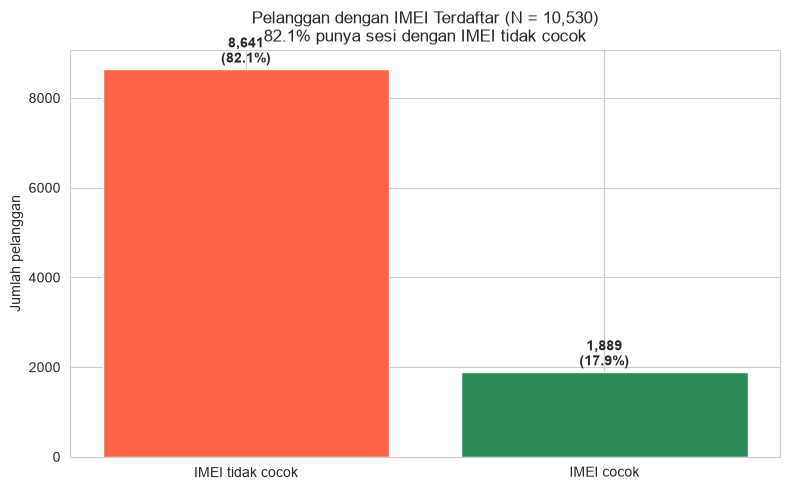

In [31]:
fig, ax = plt.subplots(figsize=(8, 5))

kategori = ['IMEI tidak cocok', 'IMEI cocok']
nilai = [pelanggan_kena_mismatch, total_pelanggan_bundling - pelanggan_kena_mismatch]

batang = ax.bar(kategori, nilai, color=['tomato', 'seagreen'])
ax.set_title(f'Pelanggan dengan IMEI Terdaftar (N = {total_pelanggan_bundling:,})\n'
             f'{persen_pelanggan:.1f}% punya sesi dengan IMEI tidak cocok')
ax.set_ylabel('Jumlah pelanggan')

for b, v in zip(batang, nilai):
    ax.text(b.get_x() + b.get_width()/2, v + 150, f'{v:,}\n({v/total_pelanggan_bundling*100:.1f}%)',
            ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

> ### 📌 INSIGHT
>
> **Melakukan :** Menghitung jumlah sesi dan jumlah pelanggan yang `used_imei`-nya berbeda dari `registered_imei`.
>
> **Output :** Pada tingkat sesi, ditemukan **17.928 dari 89.070 sesi (20,13%)** yang IMEI-nya tidak cocok. Pada tingkat pelanggan, angkanya jauh lebih besar: **8.641 dari 10.530 pelanggan (82,06%)** memiliki minimal satu sesi dengan IMEI tidak cocok.
>
> **Alasan :** Apabila angka ini diterima apa adanya, kesimpulannya sangat mengkhawatirkan — **8 dari 10 peserta program bundling** terindikasi memakai kuota bersubsidi pada perangkat di luar yang didaftarkan. Namun angka sebesar ini justru **mencurigakan**: sangat tidak masuk akal apabila 82% peserta program melakukan pelanggaran yang sama. Sebelum dilaporkan kepada manajemen, temuan ini **perlu diuji terlebih dahulu** — dan itulah yang dilakukan pada pertanyaan kedua.

## 8.2 Pertanyaan 2 — Apakah Indikasi Tersebut Valid?

Angka 82% terlalu besar untuk langsung dipercaya. Sebelum dilaporkan, temuan tersebut perlu diuji melalui tiga pemeriksaan:

1. **Dari mana** sebenarnya mismatch tersebut berasal?
2. Apakah perangkat pelanggan **benar-benar berpindah**?
3. Apakah kejanggalan ini **hanya menimpa kelompok pelanggan tertentu**?

In [32]:
# Pemeriksaan 1: dari mana mismatch ini berasal?
imei_pada_sesi_mismatch = sesi_bundling.loc[sesi_bundling['is_imei_mismatch'], 'used_imei'].value_counts()

print("=== IMEI yang muncul pada sesi-sesi mismatch ===")
display(imei_pada_sesi_mismatch.head(10))

print(f"Jumlah IMEI berbeda pada seluruh sesi mismatch : {len(imei_pada_sesi_mismatch)}")
print(f"Sesi mismatch yang memakai IMEI '350000009999999' : {sesi_bundling['is_imei_janggal'].sum():,}")
print(f"Total sesi mismatch                               : {jumlah_sesi_mismatch:,}")

=== IMEI yang muncul pada sesi-sesi mismatch ===


used_imei
350000009999999    17928
Name: count, dtype: int64

Jumlah IMEI berbeda pada seluruh sesi mismatch : 1
Sesi mismatch yang memakai IMEI '350000009999999' : 17,928
Total sesi mismatch                               : 17,928


In [33]:
# Pemeriksaan 2: apakah perangkatnya benar-benar berpindah?
# Untuk setiap pelanggan bundling, dihitung total sesi dan berapa yang mismatch
per_pelanggan = sesi_bundling.groupby('msisdn')['is_imei_mismatch'].agg(['size', 'sum'])
per_pelanggan.columns = ['total_sesi', 'sesi_mismatch']

kena_mismatch = per_pelanggan[per_pelanggan['sesi_mismatch'] > 0]
campur = kena_mismatch[kena_mismatch['sesi_mismatch'] < kena_mismatch['total_sesi']]
semua_mismatch = kena_mismatch[kena_mismatch['sesi_mismatch'] == kena_mismatch['total_sesi']]

print("=== Pola sesi pada pelanggan yang terkena mismatch ===")
print(f"Total pelanggan yang terkena mismatch     : {len(kena_mismatch):,}")
print(f"  -> Punya sesi COCOK juga (campur)       : {len(campur):,} ({len(campur)/len(kena_mismatch)*100:.2f}%)")
print(f"  -> SELURUH sesinya mismatch             : {len(semua_mismatch):,} ({len(semua_mismatch)/len(kena_mismatch)*100:.2f}%)")
print()
print(f"Rata-rata total sesi per pelanggan campur   : {campur['total_sesi'].mean():.1f} sesi")
print(f"Rata-rata sesi mismatch per pelanggan campur: {campur['sesi_mismatch'].mean():.1f} sesi")

=== Pola sesi pada pelanggan yang terkena mismatch ===
Total pelanggan yang terkena mismatch     : 8,641
  -> Punya sesi COCOK juga (campur)       : 8,629 (99.86%)
  -> SELURUH sesinya mismatch             : 12 (0.14%)

Rata-rata total sesi per pelanggan campur   : 8.8 sesi
Rata-rata sesi mismatch per pelanggan campur: 2.1 sesi


In [34]:
# Menampilkan riwayat 1 pelanggan sebagai contoh nyata
contoh_msisdn = campur.index[0]
riwayat = df_clean[df_clean['msisdn'] == contoh_msisdn].sort_values('session_time').copy()

# Nomor HP disamarkan sebagian. IMEI tetap ditampilkan penuh karena justru
# pola selang-seling antar IMEI itulah yang menjadi bukti utama.
riwayat['msisdn_samar'] = riwayat['msisdn'].str[:4] + '******' + riwayat['msisdn'].str[-2:]

print(f"=== Riwayat sesi pelanggan {contoh_msisdn[:4]}******{contoh_msisdn[-2:]} ===")
print(f"IMEI yang didaftarkan: {riwayat['registered_imei'].iloc[0]}")
print()
display(riwayat[['msisdn_samar', 'session_time', 'used_imei', 'registered_imei', 'is_imei_mismatch']])

=== Riwayat sesi pelanggan 0811******95 ===
IMEI yang didaftarkan: 350000000328759



,msisdn_samar,session_time,used_imei,registered_imei,is_imei_mismatch
240814,0811******95,2023-03-05 13:11:00,350000009999999,350000000328759,True
149163,0811******95,2023-03-08 19:05:00,350000000328759,350000000328759,False
284539,0811******95,2023-03-11 06:41:00,350000009999999,350000000328759,True
264020,0811******95,2023-03-12 06:56:00,350000000328759,350000000328759,False
166363,0811******95,2023-03-17 04:06:00,350000000328759,350000000328759,False
255390,0811******95,2023-03-27 00:54:00,350000000328759,350000000328759,False
201572,0811******95,2023-04-04 18:47:00,350000000328759,350000000328759,False
238121,0811******95,2023-04-04 21:21:00,350000000328759,350000000328759,False
90001,0811******95,2023-04-10 08:09:00,350000000328759,350000000328759,False
183281,0811******95,2023-04-12 02:00:00,350000000328759,350000000328759,False


In [35]:
# Pemeriksaan 3: apakah kejanggalan ini hanya menimpa pelanggan ber-IMEI terdaftar?
tabel_perbandingan = pd.crosstab(
    df_clean['is_bundling_customer'],
    df_clean['is_imei_janggal'],
    margins=True
)
print("=== Jumlah sesi: kelompok pelanggan vs kemunculan IMEI janggal ===")
display(tabel_perbandingan)

persen_janggal = df_clean.groupby('is_bundling_customer')['is_imei_janggal'].mean() * 100

print("=== Persentase sesi yang memakai IMEI janggal ===")
print(f"Pelanggan TANPA IMEI terdaftar : {persen_janggal[False]:.2f}%")
print(f"Pelanggan DENGAN IMEI terdaftar: {persen_janggal[True]:.2f}%")
print()
print("IMEI janggal ini TIDAK PERNAH muncul pada pelanggan tanpa IMEI terdaftar.")

=== Jumlah sesi: kelompok pelanggan vs kemunculan IMEI janggal ===


is_imei_janggal,False,True,All
is_bundling_customer,,,
False,207917,0,207917
True,71142,17928,89070
All,279059,17928,296987


=== Persentase sesi yang memakai IMEI janggal ===
Pelanggan TANPA IMEI terdaftar : 0.00%
Pelanggan DENGAN IMEI terdaftar: 20.13%

IMEI janggal ini TIDAK PERNAH muncul pada pelanggan tanpa IMEI terdaftar.


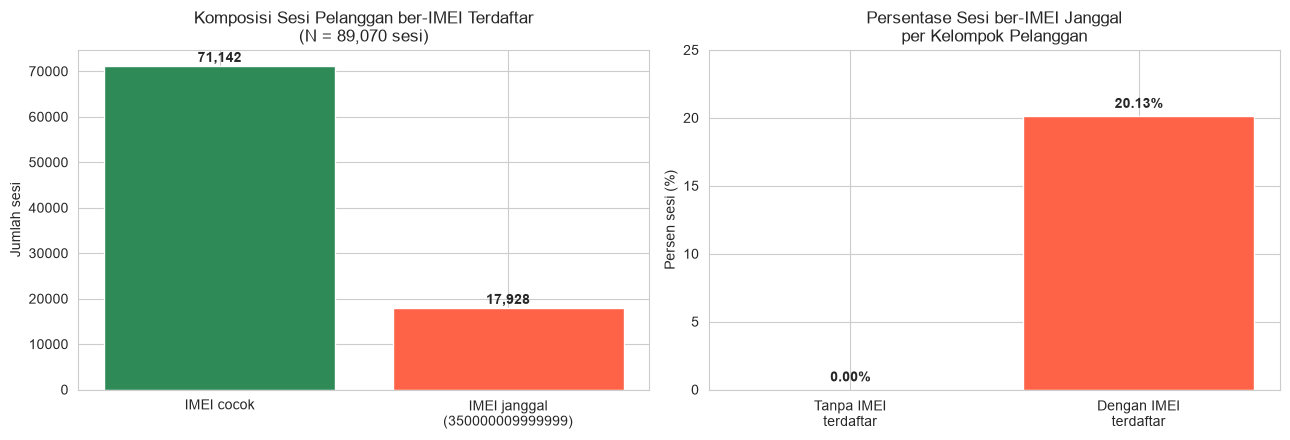

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Kiri: komposisi sesi bundling
komposisi = ['IMEI cocok', 'IMEI janggal\n(350000009999999)']
nilai_komposisi = [len(sesi_bundling) - jumlah_sesi_mismatch, jumlah_sesi_mismatch]
axes[0].bar(komposisi, nilai_komposisi, color=['seagreen', 'tomato'])
axes[0].set_title(f'Komposisi Sesi Pelanggan ber-IMEI Terdaftar\n(N = {len(sesi_bundling):,} sesi)')
axes[0].set_ylabel('Jumlah sesi')
for i, v in enumerate(nilai_komposisi):
    axes[0].text(i, v + 900, f'{v:,}', ha='center', fontweight='bold')

# Kanan: perbandingan dua kelompok pelanggan
kelompok = ['Tanpa IMEI\nterdaftar', 'Dengan IMEI\nterdaftar']
nilai_persen = [persen_janggal[False], persen_janggal[True]]
axes[1].bar(kelompok, nilai_persen, color=['steelblue', 'tomato'])
axes[1].set_title('Persentase Sesi ber-IMEI Janggal\nper Kelompok Pelanggan')
axes[1].set_ylabel('Persen sesi (%)')
axes[1].set_ylim(0, 25)
for i, v in enumerate(nilai_persen):
    axes[1].text(i, v + 0.6, f'{v:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

> ### 📌 INSIGHT
>
> **Melakukan apa:** Menelusuri asal-usul sesi mismatch, memeriksa pola sesi pada setiap pelanggan, serta membandingkan kemunculan IMEI janggal antara pelanggan ber-IMEI terdaftar dan pelanggan biasa.
>
> **Outputnya apa:** **Seluruh 17.928 sesi mismatch berasal dari satu nilai IMEI yang sama**, yaitu `350000009999999` — tidak ada satu pun IMEI lain. Pemeriksaan pola sesi menunjukkan **8.629 dari 8.641 pelanggan (99,86%)** memiliki **campuran**: sebagian sesinya ber-IMEI benar, sebagian ber-IMEI janggal, dan keduanya muncul **selang-seling** sepanjang waktu (lihat contoh riwayat pelanggan di atas). Rata-rata, dari 8,8 sesi per pelanggan hanya 2,1 sesi yang janggal. Perbandingan antar kelompok menunjukkan IMEI janggal ini muncul pada **20,13% sesi pelanggan ber-IMEI terdaftar**, namun **0,00% pada pelanggan tanpa IMEI terdaftar**.
>
> **Alasannya apa:** Ketiga bukti tersebut menunjukkan indikasi 82% itu **belum bisa dipercaya sebagai indikasi penyalahgunaan**. Pertama, satu perangkat fisik sangat tidak mungkin dipakai oleh 8.641 nomor berbeda secara bersamaan. Kedua — dan ini yang paling menentukan — apabila pelanggan benar-benar menjual perangkatnya, maka **seluruh sesi setelah tanggal penjualan** akan memakai IMEI baru dan tidak akan kembali lagi. Kenyataannya IMEI asli **muncul kembali** setelah sesi janggal. Pola ini **tidak sesuai dengan perpindahan perangkat permanen**, dan lebih menunjuk pada masalah **pencatatan**. Ketiga, pola angka `35000000` diikuti `9999999` merupakan ciri khas **nilai isian bawaan sistem**, bukan pola nomor seri perangkat pada umumnya.
>
> **Catatan metode:** perbandingan di atas sengaja disajikan sebagai **tabel dan persentase**, bukan uji statistik. Uji asosiasi seperti *Chi-Square* akan otomatis menghasilkan p-value sangat kecil, karena salah satu selnya bernilai **nol secara struktural** — IMEI janggal memang hanya mungkin muncul pada pelanggan yang punya IMEI terdaftar. Uji semacam itu tidak menambah informasi apa pun di luar yang sudah terlihat pada tabel.

## 8.3 Pertanyaan 3 — Error Sistem atau Penyalahgunaan?

Setelah diketahui bahwa mismatch berasal dari satu nilai IMEI, perlu dipastikan apakah kemunculannya menunjukkan **pola perilaku manusia** atau **pola mesin**.

Logikanya sederhana: **perilaku manusia tidak pernah merata.** Manusia mengelompok — pada waktu tertentu, pada barang yang lebih mahal, pada orang tertentu. Sebaliknya, error sistem cenderung muncul dengan tingkat yang **sama rata** tanpa memandang konteks.

Karena itu, tingkat kemunculan IMEI janggal akan diperiksa dari **empat sudut** yang berbeda.

In [37]:
# Sudut 1: per bulan
per_bulan = sesi_bundling.groupby(sesi_bundling['session_time'].dt.to_period('M'))['is_imei_mismatch'].agg(['size', 'mean'])
per_bulan.columns = ['jumlah_sesi', 'rate']
per_bulan['rate_persen'] = (per_bulan['rate'] * 100).round(2)

print("=== Tingkat kemunculan IMEI janggal PER BULAN ===")
display(per_bulan[['jumlah_sesi', 'rate_persen']])

=== Tingkat kemunculan IMEI janggal PER BULAN ===


,jumlah_sesi,rate_persen
session_time,,
2022-12,62,22.58
2023-01,2775,20.50
2023-02,6657,20.31
2023-03,9136,20.44
2023-04,8636,19.82
2023-05,9290,20.46
2023-06,8971,19.92
2023-07,9274,20.43
2023-08,9351,19.77


In [38]:
# Sudut 2: per jam  |  Sudut 3: per hari dalam seminggu
per_jam = sesi_bundling.groupby(sesi_bundling['session_time'].dt.hour)['is_imei_mismatch'].mean() * 100
per_hari = sesi_bundling.groupby(sesi_bundling['session_time'].dt.dayofweek)['is_imei_mismatch'].mean() * 100

print("=== Rentang tingkat kemunculan ===")
print(f"Per bulan : {per_bulan['rate_persen'].min():.2f}% sampai {per_bulan['rate_persen'].max():.2f}%")
print(f"Per jam   : {per_jam.min():.2f}% sampai {per_jam.max():.2f}%")
print(f"Per hari  : {per_hari.min():.2f}% sampai {per_hari.max():.2f}%")

=== Rentang tingkat kemunculan ===
Per bulan : 19.67% sampai 22.58%
Per jam   : 18.62% sampai 21.84%
Per hari  : 19.58% sampai 20.57%


In [39]:
# Sudut 4: per paket -- ini pembanding yang paling menentukan
per_paket = sesi_bundling.groupby('package_name')['is_imei_mismatch'].mean() * 100
per_paket = per_paket.round(2).sort_values()

harga_paket = df_package.set_index('package_name')['price']
tabel_paket = pd.DataFrame({
    'harga_paket': harga_paket,
    'rate_imei_janggal_persen': per_paket
}).dropna().sort_values('harga_paket', ascending=False)

print("=== Tingkat kemunculan IMEI janggal PER PAKET ===")
display(tabel_paket)

print(f"Paket TERMAHAL  : Halo Bundling iPhone (Rp 250.000) -> {per_paket['Halo Bundling iPhone']:.2f}%")
print(f"Paket TERMURAH  : Kuota Ketengan YouTube (Rp 5.000) -> {per_paket['Kuota Ketengan YouTube']:.2f}%")

=== Tingkat kemunculan IMEI janggal PER PAKET ===


,harga_paket,rate_imei_janggal_persen
package_name,,
Halo Bundling iPhone,250000,20.00
Halo Bundling Samsung,200000,19.72
Internet OMG! 100GB,160000,20.38
Internet OMG! 50GB,110000,19.64
Combo Sakti 25GB,100000,20.87
Combo Sakti 15GB,75000,20.56
Promo Perdana 30GB,45000,20.09
Promo Perdana 15GB,25000,19.46
Kuota Ketengan TikTok,6000,19.70


Paket TERMAHAL  : Halo Bundling iPhone (Rp 250.000) -> 20.00%
Paket TERMURAH  : Kuota Ketengan YouTube (Rp 5.000) -> 20.86%


### Uji statistik: menguji langsung dugaan penyalahgunaan

Perbandingan di atas sudah menunjukkan tingkat kemunculan yang datar. Namun untuk memastikan kedataran itu bukan sekadar kebetulan, dilakukan **uji proporsi dua kelompok**.

Logika ujinya berangkat dari dugaan penyalahgunaan itu sendiri:

> **Apabila ini benar-benar penyalahgunaan**, maka paket yang **mahal** seharusnya memiliki tingkat kejanggalan yang **lebih tinggi** — karena keuntungan dari mengakalinya jauh lebih besar.

Yang dibandingkan:
* **Paket mahal** — Halo Bundling iPhone (Rp 250.000) dan Halo Bundling Samsung (Rp 200.000)
* **Paket murah** — Kuota Ketengan YouTube (Rp 5.000) dan Kuota Ketengan TikTok (Rp 6.000)

Hipotesisnya:
* **Ho** — proporsi IMEI janggal **sama** antara paket mahal dan paket murah
* **Ha** — proporsi IMEI janggal **berbeda** antara paket mahal dan paket murah

Uji ini penting karena **hasilnya bisa saja membantah kesimpulan analisis ini**. Apabila paket mahal terbukti lebih tinggi secara signifikan, maka dugaan penyalahgunaan justru menguat.

In [40]:
# Ho : proporsi IMEI janggal SAMA antara paket mahal dan paket murah
# Ha : proporsi IMEI janggal BERBEDA antara paket mahal dan paket murah

paket_mahal = sesi_bundling[sesi_bundling['package_code'].isin(['PKG-003', 'PKG-004'])]
paket_murah = sesi_bundling[sesi_bundling['package_code'].isin(['PKG-009', 'PKG-010'])]

print("=== Membandingkan paket termahal dengan paket termurah ===")
print(f"Paket mahal (Rp 200.000 - 250.000) : {len(paket_mahal):,} sesi | {paket_mahal['is_imei_janggal'].mean()*100:.2f}% janggal")
print(f"Paket murah (Rp 5.000 - 6.000)     : {len(paket_murah):,} sesi | {paket_murah['is_imei_janggal'].mean()*100:.2f}% janggal")
print()

jumlah_janggal = [paket_mahal['is_imei_janggal'].sum(), paket_murah['is_imei_janggal'].sum()]
jumlah_sesi = [len(paket_mahal), len(paket_murah)]

zscore_paket, pval_paket = proportions_ztest(jumlah_janggal, jumlah_sesi)

print("=== Uji proporsi dua kelompok (proportions_ztest) ===")
print(f"z-score : {zscore_paket:.4f}")
print(f"p-value : {pval_paket:.4f}")
print()

if pval_paket <= 0.05:
    print('Tolak Ho')
else:
    print('Gagal menolak Ho')

=== Membandingkan paket termahal dengan paket termurah ===
Paket mahal (Rp 200.000 - 250.000) : 17,818 sesi | 19.86% janggal
Paket murah (Rp 5.000 - 6.000)     : 17,564 sesi | 20.29% janggal

=== Uji proporsi dua kelompok (proportions_ztest) ===
z-score : -0.9953
p-value : 0.3196

Gagal menolak Ho


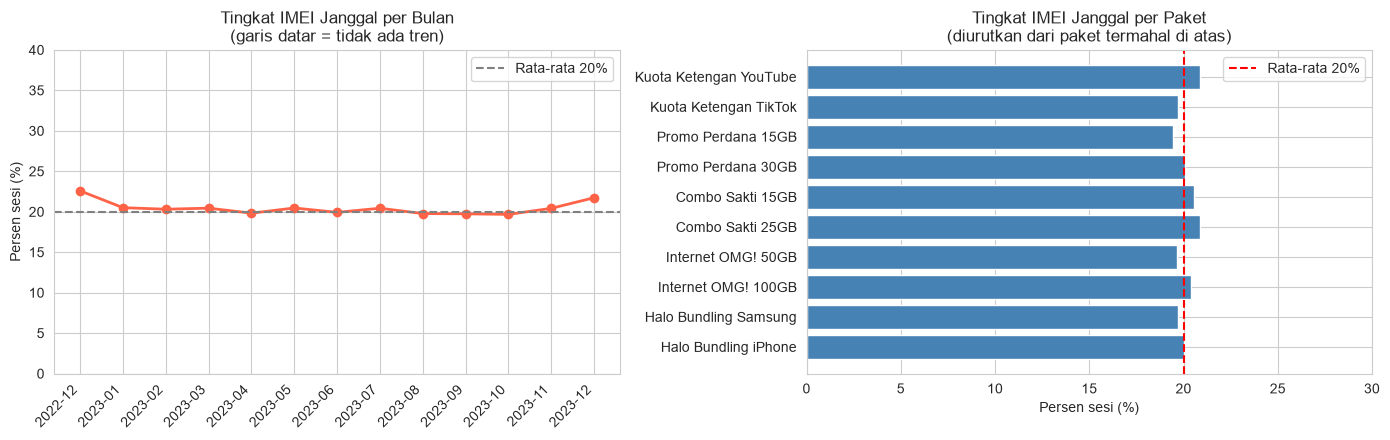

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Kiri: rate per bulan
sumbu_x = range(len(per_bulan))
axes[0].plot(sumbu_x, per_bulan['rate_persen'], marker='o', color='tomato', linewidth=2)
axes[0].axhline(20, color='gray', linestyle='--', label='Rata-rata 20%')
axes[0].set_xticks(sumbu_x)
axes[0].set_xticklabels([str(b) for b in per_bulan.index], rotation=45, ha='right')
axes[0].set_ylim(0, 40)
axes[0].set_title('Tingkat IMEI Janggal per Bulan\n(garis datar = tidak ada tren)')
axes[0].set_ylabel('Persen sesi (%)')
axes[0].legend()

# Kanan: rate per paket, diurutkan berdasarkan harga
axes[1].barh(tabel_paket.index, tabel_paket['rate_imei_janggal_persen'], color='steelblue')
axes[1].axvline(20, color='red', linestyle='--', label='Rata-rata 20%')
axes[1].set_xlim(0, 30)
axes[1].set_title('Tingkat IMEI Janggal per Paket\n(diurutkan dari paket termahal di atas)')
axes[1].set_xlabel('Persen sesi (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

> ### 📌 INSIGHT
>
> **Melakukan :** Memeriksa tingkat kemunculan IMEI janggal dari empat sudut yang berbeda (per bulan, per jam, per hari, per paket), lalu menguji secara statistik apakah paket mahal berbeda dari paket murah menggunakan **uji proporsi dua kelompok**.
>
> **Output :** Hasilnya **datar di semua sudut**, selalu berada di sekitar **20%**: per bulan berkisar **19,67%–22,58%**, per jam **18,62%–21,84%**, per hari **19,58%–20,57%**, dan per paket **19,46%–20,87%**. Uji proporsi membandingkan paket mahal (**19,86%**) dengan paket murah (**20,29%**) menghasilkan p-value **0,3196** sehingga **Gagal menolak Ho** — tidak ada perbedaan yang signifikan secara statistik. Bahkan arah selisihnya justru berlawanan dengan dugaan penyalahgunaan: paket murah sedikit lebih tinggi.
>
> **Alasan :** Keteraturan inilah buktinya. Apabila ini benar-benar penyalahgunaan, seharusnya muncul **lonjakan pada bulan tertentu** (karena perangkat dijual pada satu titik waktu), **terkonsentrasi pada paket mahal** (karena keuntungannya lebih besar), dan **sebagian pelanggan memiliki 100% sesi mismatch** (karena perangkatnya sudah dijual permanen). Tidak satu pun dari ketiganya terjadi. Tidak masuk akal apabila seseorang bersusah payah mengakali paket Rp 5.000 dengan usaha yang sama seperti mengakali paket Rp 250.000. Tingkat kemunculan yang **konstan 1 dari 5 sesi tanpa memandang siapa, kapan, dan paket apa** jauh lebih menyerupai **proses otomatis dari sistem** dibandingkan keputusan manusia. Perlu ditegaskan bahwa uji ini **tidak membuktikan** penyebab teknisnya — yang ditunjukkan adalah dugaan penyalahgunaan **tidak didukung data**, sementara penyebab sesungguhnya masih memerlukan konfirmasi kepada pemilik sistem.

## 8.4 Pertanyaan 4 — Kejanggalan Apa Lagi yang Ada di Luar IMEI?

Apabila sistem pencatatan Telkomsel bermasalah pada kolom IMEI, kemungkinan besar masalahnya tidak berhenti di situ. Pemeriksaan dilanjutkan pada tiga kolom lain, lalu dihitung berapa banyak pelanggan yang terdampak secara keseluruhan.

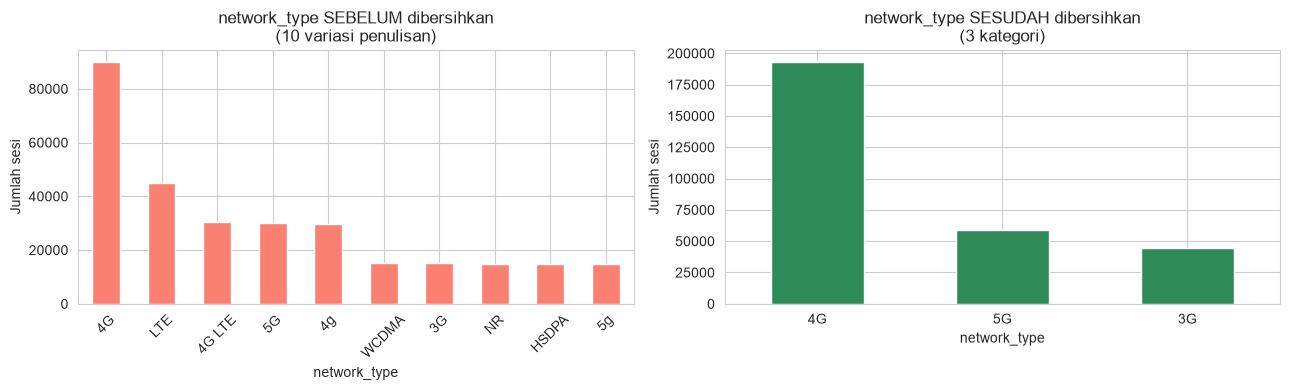

In [42]:
# Kejanggalan 1: inkonsistensi penulisan network_type (sudah dibersihkan pada tahap cleaning)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

network_type_sebelum.plot(kind='bar', ax=axes[0], color='salmon')
axes[0].set_title(f'network_type SEBELUM dibersihkan\n({len(network_type_sebelum)} variasi penulisan)')
axes[0].set_ylabel('Jumlah sesi')
axes[0].tick_params(axis='x', rotation=45)

df_clean['network_type'].value_counts().plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title(f"network_type SESUDAH dibersihkan\n({df_clean['network_type'].nunique()} kategori)")
axes[1].set_ylabel('Jumlah sesi')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [43]:
# Kejanggalan 2: logical error -- sesi tercatat sebelum kartu diaktifkan
jumlah_logical_error = df_clean['is_logical_error'].sum()
persen_logical_error = jumlah_logical_error / len(df_clean) * 100
pelanggan_logical_error = df_clean.loc[df_clean['is_logical_error'], 'msisdn'].nunique()

print("=== Logical error: sesi terjadi SEBELUM kartu aktif ===")
print(f"Jumlah sesi      : {jumlah_logical_error:,} dari {len(df_clean):,} ({persen_logical_error:.2f}%)")
print(f"Jumlah pelanggan : {pelanggan_logical_error:,}")
print()

# Seberapa jauh sesi mendahului aktivasi?
selisih_hari = (df_clean.loc[df_clean['is_logical_error'], 'session_time'] -
                df_clean.loc[df_clean['is_logical_error'], 'activation_date']).dt.days

print("Sesi mendahului tanggal aktivasi sebanyak:")
print(f"  Paling sedikit : {abs(selisih_hari.max())} hari")
print(f"  Paling banyak  : {abs(selisih_hari.min())} hari")

=== Logical error: sesi terjadi SEBELUM kartu aktif ===
Jumlah sesi      : 11,875 dari 296,987 (4.00%)
Jumlah pelanggan : 10,083

Sesi mendahului tanggal aktivasi sebanyak:
  Paling sedikit : 1 hari
  Paling banyak  : 9 hari


In [44]:
# UJI STATISTIK: apakah logical error lebih sering terjadi pada pelanggan bundling?
# Ho : proporsi logical error SAMA antara pelanggan ber-IMEI terdaftar dan tanpa IMEI terdaftar
# Ha : proporsi logical error BERBEDA antara kedua kelompok

kelompok_bundling = df_clean.loc[df_clean['is_bundling_customer'], 'is_logical_error']
kelompok_non_bundling = df_clean.loc[~df_clean['is_bundling_customer'], 'is_logical_error']

jumlah_error = [kelompok_bundling.sum(), kelompok_non_bundling.sum()]
jumlah_total = [len(kelompok_bundling), len(kelompok_non_bundling)]

zscore, pval_z = proportions_ztest(jumlah_error, jumlah_total)

print("=== Uji proporsi dua kelompok (proportions_ztest) ===")
print(f"Pelanggan DENGAN IMEI terdaftar : {kelompok_bundling.mean()*100:.2f}% logical error")
print(f"Pelanggan TANPA IMEI terdaftar  : {kelompok_non_bundling.mean()*100:.2f}% logical error")
print()
print(f"z-score : {zscore:.4f}")
print(f"p-value : {pval_z:.4f}")
print()

if pval_z <= 0.05:
    print('Tolak Ho')
else:
    print('Gagal menolak Ho')

=== Uji proporsi dua kelompok (proportions_ztest) ===
Pelanggan DENGAN IMEI terdaftar : 4.03% logical error
Pelanggan TANPA IMEI terdaftar  : 3.98% logical error

z-score : 0.6243
p-value : 0.5324

Gagal menolak Ho


In [45]:
# Kejanggalan 3: NIK/KK kosong -- pelanggaran regulasi registrasi prabayar
jumlah_nik_kosong = (df_subs_clean['nik_kk_status'] == 'Missing').sum()
persen_nik_kosong = jumlah_nik_kosong / len(df_subs_clean) * 100

print("=== NIK/KK belum terverifikasi ===")
print(f"Jumlah nomor : {jumlah_nik_kosong:,} dari {len(df_subs_clean):,} ({persen_nik_kosong:.2f}%)")

=== NIK/KK belum terverifikasi ===
Jumlah nomor : 5,202 dari 34,999 (14.86%)


In [46]:
# Menghitung TOTAL pelanggan yang datanya bermasalah
pelanggan_mismatch = set(df_clean.loc[df_clean['is_imei_mismatch'], 'msisdn'])
pelanggan_logical = set(df_clean.loc[df_clean['is_logical_error'], 'msisdn'])
pelanggan_nik = set(df_subs_clean.loc[df_subs_clean['nik_kk_status'] == 'Missing', 'msisdn'])

pelanggan_terdampak = pelanggan_mismatch | pelanggan_logical | pelanggan_nik
total_pelanggan = df_subs_clean['msisdn'].nunique()

print("=== Jumlah pelanggan terdampak per jenis kejanggalan ===")
print(f"IMEI janggal         : {len(pelanggan_mismatch):,}")
print(f"Logical error        : {len(pelanggan_logical):,}")
print(f"NIK/KK kosong        : {len(pelanggan_nik):,}")
print(f"Penjumlahan langsung : {len(pelanggan_mismatch) + len(pelanggan_logical) + len(pelanggan_nik):,}  <- ADA YANG TERHITUNG DUA KALI")
print()
print(f"Pelanggan unik yang bermasalah : {len(pelanggan_terdampak):,}")
print(f"Dari total pelanggan           : {total_pelanggan:,}")
print(f"Persentase                     : {len(pelanggan_terdampak)/total_pelanggan*100:.2f}%")

=== Jumlah pelanggan terdampak per jenis kejanggalan ===
IMEI janggal         : 8,641
Logical error        : 10,083
NIK/KK kosong        : 5,202
Penjumlahan langsung : 23,926  <- ADA YANG TERHITUNG DUA KALI

Pelanggan unik yang bermasalah : 18,967
Dari total pelanggan           : 34,999
Persentase                     : 54.19%


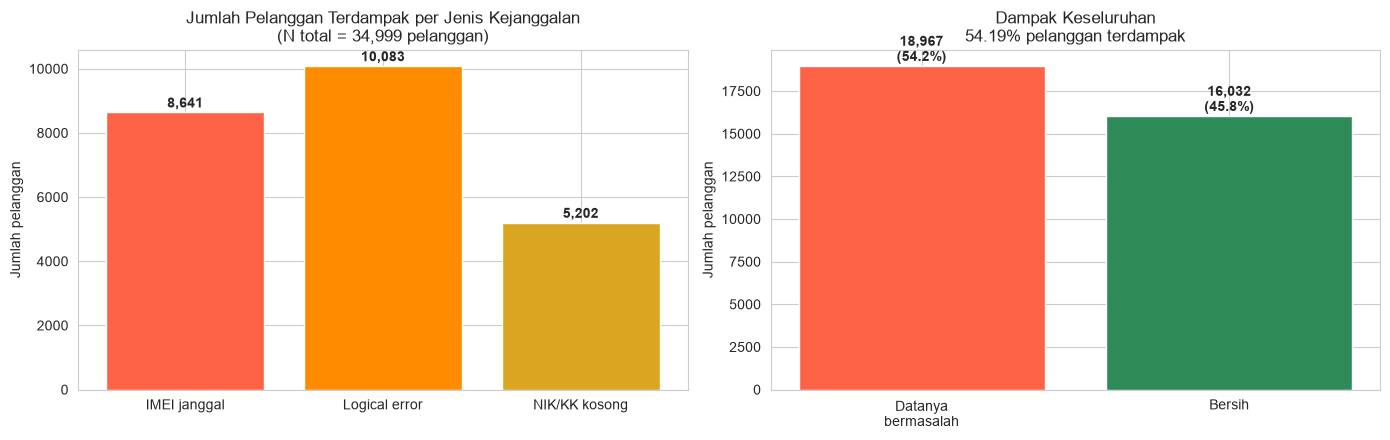

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Kiri: jumlah pelanggan per jenis kejanggalan
jenis_kejanggalan = ['IMEI janggal', 'Logical error', 'NIK/KK kosong']
jumlah_kejanggalan = [len(pelanggan_mismatch), len(pelanggan_logical), len(pelanggan_nik)]

batang1 = axes[0].bar(jenis_kejanggalan, jumlah_kejanggalan, color=['tomato', 'darkorange', 'goldenrod'])
axes[0].set_title(f'Jumlah Pelanggan Terdampak per Jenis Kejanggalan\n(N total = {total_pelanggan:,} pelanggan)')
axes[0].set_ylabel('Jumlah pelanggan')
for b, v in zip(batang1, jumlah_kejanggalan):
    axes[0].text(b.get_x() + b.get_width()/2, v + 150, f'{v:,}', ha='center', fontweight='bold')

# Kanan: total pelanggan terdampak vs bersih
labels = ['Datanya\nbermasalah', 'Bersih']
nilai2 = [len(pelanggan_terdampak), total_pelanggan - len(pelanggan_terdampak)]
batang2 = axes[1].bar(labels, nilai2, color=['tomato', 'seagreen'])
axes[1].set_title(f'Dampak Keseluruhan\n{len(pelanggan_terdampak)/total_pelanggan*100:.2f}% pelanggan terdampak')
axes[1].set_ylabel('Jumlah pelanggan')
for b, v in zip(batang2, nilai2):
    axes[1].text(b.get_x() + b.get_width()/2, v + 300, f'{v:,}\n({v/total_pelanggan*100:.1f}%)',
                 ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

> ### 📌 INSIGHT
>
> **Melakukan :** Memeriksa tiga kejanggalan lain di luar IMEI, menguji apakah *logical error* terkait dengan status bundling menggunakan **uji proporsi dua kelompok**, serta menghitung total pelanggan unik yang terdampak.
>
> **Output :** Ditemukan tiga kejanggalan tambahan: **`network_type` ditulis dalam 10 variasi** untuk 3 jaringan; **11.875 sesi (4,00%) tercatat terjadi sebelum kartunya diaktifkan** — mendahului antara 1 sampai 9 hari — yang menimpa **10.083 pelanggan**; serta **5.202 nomor (14,86%) status verifikasi NIK/KK-nya kosong**. Uji proporsi menunjukkan tingkat *logical error* pada pelanggan ber-IMEI terdaftar (**4,03%**) dan tanpa IMEI terdaftar (**3,98%**) menghasilkan p-value **0,5324** sehingga **Gagal menolak Ho**. Secara keseluruhan, **18.967 dari 34.999 pelanggan (54,19%)** memiliki minimal satu penanda kualitas data yang memerlukan validasi.
>
> **Alasan :** Hasil uji proporsi tersebut justru **memperkuat kesimpulan** analisis ini: karena tidak ada perbedaan yang signifikan antar kelompok, *logical error* **bukan** masalah yang khusus menimpa peserta bundling, melainkan kejanggalan yang tersebar **merata di seluruh sistem** — pola yang sama persis dengan temuan pada pertanyaan ketiga. Perlu diperhatikan pula bahwa jumlah pelanggan terdampak **tidak boleh dihitung dengan menjumlahkan ketiga angka secara langsung**, karena satu pelanggan bisa terkena lebih dari satu jenis kejanggalan sekaligus sehingga akan terhitung ganda. Kesimpulannya, masalah pencatatan ini **bukan satu bug yang berdiri sendiri**, melainkan **pola yang berulang** di berbagai kolom — dan penanda kualitas datanya menyentuh **lebih dari separuh basis pelanggan**.

---
# 9. Kesimpulan dan Rekomendasi

Dari analisis yang telah dilakukan, kita bisa membuat kesimpulan berikut tentang **kondisi data** yang dimiliki Telkomsel:

* Dari 300.000 sesi pemakaian internet yang kita miliki, sebanyak **3.013 sesi (1%) harus dibuang** karena nilainya berada jauh di luar kewajaran — 1.469 sesi tercatat memakai data **minus 150,5 MB**, dan 1.544 sesi tercatat memakai **hampir 1 Terabyte dalam satu sesi**.
* Jenis jaringan ditulis dalam **10 variasi berbeda** padahal jaringannya hanya ada 3, karena setiap tower BTS mencatat dengan istilah yang berbeda-beda.
* Sebanyak **11.875 sesi (4%)** tercatat terjadi **sebelum kartunya sendiri diaktifkan**, mendahului antara 1 sampai 9 hari.
* Sebanyak **5.202 nomor (14,86%)** status NIK/KK-nya kosong. Perlu dicatat bahwa dari data ini kita hanya mengetahui **datanya tidak tersedia** — belum tentu registrasinya benar-benar tidak dilakukan, karena bisa juga disebabkan kegagalan sinkronisasi atau pencatatan.
* Secara keseluruhan, **18.967 dari 34.999 pelanggan (54,19%)** terkena minimal satu kejanggalan pencatatan — artinya **lebih dari separuh** basis pelanggan kita datanya bermasalah.

Selanjutnya, kesimpulan mengenai **program Device Bundling** yang menjadi fokus utama analisis ini:

* Dari 34.999 pelanggan, sebanyak **10.530 pelanggan (30%)** memiliki IMEI terdaftar, yaitu peserta program yang perangkatnya dicatat saat pembelian.
* Sebanyak **8.641 dari 10.530 pelanggan (82,06%)** terindikasi memakai perangkat yang berbeda dari yang mereka daftarkan. Apabila angka ini kita percaya begitu saja, kesimpulannya adalah **8 dari 10 peserta program melakukan pelanggaran**.
* Namun setelah ditelusuri, **seluruh 17.928 sesi** yang bermasalah tersebut ternyata berasal dari **satu nilai IMEI yang sama persis**, yaitu `350000009999999` — tidak ada satu pun IMEI lain.
* Satu perangkat fisik tidak mungkin dipakai oleh 8.641 nomor berbeda, sementara perangkat pada umumnya hanya muncul sekitar 10 kali.
* **Polanya tidak sesuai dengan perpindahan perangkat secara permanen.** Sebanyak **99,86% pelanggan** yang terkena masih memiliki sesi dengan IMEI yang benar, muncul **selang-seling** dengan sesi yang bermasalah.

Karakteristik kejanggalan IMEI ini, terutama apabila dibandingkan dengan pola penyalahgunaan yang sesungguhnya, adalah sebagai berikut:

* **Muncul hilang-timbul, bukan permanen.** Apabila pelanggan benar-benar menjual perangkatnya, IMEI lama tidak akan pernah muncul lagi setelah tanggal penjualan. Kenyataannya IMEI asli tetap muncul kembali, sehingga pola ini tidak sesuai dengan perpindahan perangkat permanen.
* **Tidak memilih paket yang mahal.** Paket Halo Bundling iPhone seharga Rp 250.000 memiliki tingkat kejanggalan **20,00%**, sementara paket Kuota Ketengan YouTube seharga Rp 5.000 justru sedikit lebih tinggi yaitu **20,86%**. Tidak masuk akal apabila ada orang yang bersusah payah mengakali paket Rp 5.000 dengan usaha yang sama seperti mengakali paket Rp 250.000.
* **Tidak menumpuk pada waktu tertentu.** Tingkatnya datar di sekitar 20% sepanjang tahun, di semua jam, dan di semua hari.
* **Diuji secara statistik.** Uji proporsi antara paket mahal (19,86%) dan paket murah (20,29%) menghasilkan p-value **0,3196** sehingga **gagal menolak Ho** — perbedaannya tidak signifikan. Uji ini sengaja dirancang agar **bisa membantah** kesimpulan analisis: apabila paket mahal terbukti lebih tinggi, dugaan penyalahgunaan justru menguat. Ternyata tidak.
* **Hanya menimpa pelanggan ber-IMEI terdaftar** (20,13%), dan **sama sekali tidak muncul** pada pelanggan lainnya (0,00%).

Keteraturan seperti ini jauh lebih menyerupai **proses otomatis dari sistem** dibandingkan keputusan manusia. Perilaku manusia selalu mengelompok — pada waktu tertentu, pada barang yang lebih menguntungkan, atau pada orang tertentu. Dengan demikian, jawaban atas pertanyaan utama project ini adalah:

> ### Data IMEI Telkomsel **belum cukup valid** untuk dijadikan dasar menindak penyalahgunaan program Device Bundling.

Kondisi ini membuat perusahaan sedang menanggung dua kerugian sekaligus. Pertama, apabila penindakan dijalankan berdasarkan data ini, **8.641 pelanggan berisiko terkena penindakan yang salah sasaran (*false detection*)**. Kedua, dan ini yang lebih merugikan, apabila memang ada pelanggan yang benar-benar menyalahgunakan program, pada data ia akan **terlihat persis sama** dengan 17.928 sesi error tersebut sehingga tidak dapat dibedakan. Artinya, program Device Bundling kita **saat ini tidak dapat diawasi sama sekali** — bukan karena tidak ada penyalahgunaan, melainkan karena alat ukurnya sedang rusak.

**Rekomendasi**
---

### 1. Terapkan perlindungan subsidi secara bertahap

Perusahaan sebaiknya tidak langsung menghentikan benefit ketika ditemukan perbedaan antara `registered_imei` dan `used_imei`. Perbedaan tersebut dapat digunakan sebagai peringatan awal, tetapi belum cukup untuk membuktikan adanya penyalahgunaan.

Penanganan dapat dilakukan secara bertahap, mulai dari memberikan notifikasi, meminta pelanggan melakukan verifikasi perangkat, hingga membatasi benefit apabila pelanggaran telah terbukti. Pendekatan ini membantu perusahaan melindungi subsidi bundling sekaligus mengurangi risiko salah sasaran, keluhan, dan hilangnya kepercayaan pelanggan.

### 2. Implementasikan IMEI Locking setelah akurasi data terverifikasi

IMEI Locking dapat diterapkan untuk memastikan bahwa kuota promo bundling hanya digunakan pada perangkat yang terdaftar. Namun, kebijakan ini sebaiknya dijalankan setelah perusahaan memastikan bahwa sistem pencatatan IMEI sudah akurat dan nilai IMEI anomali tidak lagi memengaruhi hasil monitoring.

Jika SIM terdeteksi berpindah ke perangkat lain, benefit promo dapat ditangguhkan sementara sampai pelanggan menyelesaikan proses verifikasi, sedangkan kuota reguler tetap dapat digunakan. Dengan demikian, perusahaan dapat melindungi subsidi tanpa langsung menghentikan seluruh layanan pelanggan.

### 3. Jadikan kualitas data sebagai syarat peluncuran kebijakan bundling

Sebelum mengaktifkan blacklist, pemblokiran, atau penghentian benefit otomatis, perusahaan perlu menetapkan standar minimum kualitas data. Data yang digunakan untuk mengambil keputusan harus sudah melalui proses pemeriksaan dan memenuhi standar kelayakan.

Nilai IMEI yang terindikasi anomali tidak boleh digunakan sebagai dasar penindakan pelanggan. Payload negatif atau tidak wajar perlu dikeluarkan dari laporan, penulisan jenis jaringan harus menggunakan kategori yang konsisten, dan status registrasi pelanggan harus dapat ditelusuri.

Secara bisnis, standar tersebut dapat mencegah keputusan yang salah, mengurangi potensi komplain, dan menjaga kepercayaan pelanggan terhadap program bundling.

### 4. Hitung ulang potensi kebocoran subsidi setelah kualitas data diperbaiki

Angka 82% belum dapat dianggap sebagai tingkat fraud karena sebagian besar indikasi mismatch berkaitan dengan satu nilai IMEI yang muncul secara tidak wajar. Oleh karena itu, perusahaan perlu menghitung ulang tingkat penyalahgunaan setelah kualitas data IMEI diperbaiki dan kasus anomali dipisahkan dari analisis.

Penghitungan ulang perlu mencakup jumlah pelanggan yang benar-benar menggunakan perangkat berbeda, nilai benefit yang digunakan tidak sesuai ketentuan, potensi subsidi yang dapat diselamatkan, serta biaya penerapan monitoring dan verifikasi. Hasilnya dapat digunakan untuk menilai apakah kebijakan IMEI Locking layak diterapkan dari sisi finansial dan operasional.


---

**Keterbatasan analisis :**

* **Penyebab teknis dari kejanggalan ini belum bisa dipastikan** hanya dari data. Yang bisa ditunjukkan adalah nilai tersebut sangat tidak wajar sebagai identitas satu perangkat, dan polanya tidak sesuai dengan perpindahan perangkat permanen. Penyebabnya memerlukan konfirmasi tim Network/OSS.
* **Tidak tersedia data lokasi** pada ketiga tabel, sehingga penyebaran masalah per wilayah belum bisa dipetakan.
* **Kolom `is_bundling_customer` berarti "memiliki IMEI terdaftar"**, bukan "membeli paket bundling". Karena itu istilah yang dipakai sepanjang analisis ini adalah *pelanggan dengan IMEI terdaftar*.
* **Data yang dianalisis hanya mencakup periode 2023**, sehingga belum bisa dipastikan apakah persoalan ini juga terjadi pada periode sebelumnya.
* **Belum tersedia data pembanding** berupa kasus penyalahgunaan yang sudah terbukti, sehingga tidak ada acuan untuk menilai seberapa akurat penandaan IMEI ini dalam kondisi normal.